# PCA to DMD: Interactive Demo

**Chinmay Ratnaparkhe | Manohar Lab | University of Washington**

---

### Contents

1. [Setup & Helper Functions](#Cell-0:-Setup-&-Helper-Functions)
2. [The Physical Setup](#The-Physical-Setup:-What-Are-We-Looking-At?)
3. [Warm-Up: DMD on a Sine Wave](#Cell-1:-Warm-Up-—-DMD-on-a-Simple-Sine-Wave)
4. [Varying the Wavelength](#Cell-2:-Change-the-Wavelength,-Watch-the-Eigenvalue-Move)
5. [Scale Up to B-scans](#Cell-3:-Scale-Up-—-From-Sine-Waves-to-Ultrasound-B-scans)
6. [PCA Shuffle Test](#Cell-4:-PCA-Can't-Tell-You-the-Frequency)
7. [DMD on the B-scan](#Cell-5:-DMD-on-the-B-scan-—-Same-θ=36°-as-the-Sine-Wave!)
8. [PCA vs DMD Visual Comparison](#Visual-Comparison:-What-PCA-Sees-vs.-What-DMD-Sees)
9. [Inside DMD, Step by Step](#Cell-6:-Inside-DMD-—-Step-by-Step)
10. [Choosing Rank r](#How-to-Choose-the-Truncation-Rank-r)
11. [Noise + Multiple Wrinkles](#Cell-7:-Stress-Test-—-Noise-+-Multiple-Wrinkles)
12. [Playground](#Cell-8:-Playground-—-Build-Your-Intuition!)
13. [K-Means Clustering](#Cell-9:-Application-—-Classifying-Wrinkle-Severity-with-K-Means)
14. [When DMD Struggles](#Cell-10:-When-Does-DMD-Struggle?)
15. [Summary & Resources](#Summary)

---

### DMD in a Nutshell

**Dynamic Mode Decomposition (DMD)** treats the columns of a data matrix as *sequential snapshots* and finds the best-fit linear operator that maps each column to the next.

Given a data matrix $X$ with $n$ columns, form the time-shifted pair:

$$X_1 = [x_1 \;\; x_2 \;\; \cdots \;\; x_{n-1}], \qquad X_2 = [x_2 \;\; x_3 \;\; \cdots \;\; x_n]$$

We want to find the operator $A$ such that $X_2 \approx A\, X_1$.

**Algorithm (4 steps):**

1. **SVD of $X_1$** (same decomposition that PCA uses under the hood):
$$X_1 = U\,\Sigma\,V^*$$
Truncate to rank $r$: keep $U_r,\; \Sigma_r,\; V_r$.

> *Note:* PCA technically centers the data first (subtracts the column mean), then does the SVD. Here we skip centering because in our B-scan data the mean column is just the healthy baseline, and the wrinkle information lives in the deviations. So the SVD step gives us the same spatial directions PCA would, just without the explicit centering.

2. **Build the reduced operator:**
$$\tilde{A} = U_r^*\, X_2\, V_r\, \Sigma_r^{-1} \qquad (r \times r \text{ matrix})$$

3. **Eigendecompose $\tilde{A}$:**
$$\tilde{A}\, W = W\, \Lambda$$
The eigenvalues $\lambda_k$ are complex numbers on (or near) the unit circle.

4. **Recover full DMD modes:**
$$\Phi = X_2\, V_r\, \Sigma_r^{-1}\, W$$

**The key result: eigenvalue angle = spatial frequency**

$$\theta_k = \angle\,\lambda_k \qquad \Longrightarrow \qquad \text{wavelength} = \frac{360°}{|\theta_k|} \times \text{pitch}$$

For a phased array with 1 mm element pitch and a wrinkle of wavelength $\lambda = 10\text{ mm}$:

$$\theta = \frac{360°}{10} = 36°$$

The eigenvalue sits at angle $\pm 36°$ on the unit circle. **The angle *is* the wrinkle frequency.** That's information PCA (which only gives real singular values) simply cannot provide.

Let's see it in action :)

---
## Cell 0: Setup & Helper Functions

Run this cell first! It defines three functions we'll use throughout:
- `run_dmd()` – implements DMD from scratch (no black-box libraries)
- `generate_bscan()` – creates synthetic B-scan data with controllable wrinkle parameters
- `plot_unit_circle()` – visualizes DMD eigenvalues with wavelength annotations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.gridspec as gridspec

# Plot settings for lecture readability
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'axes.grid': False,
})

# Colors
UW_PURPLE = '#4B2E83'
UW_GOLD = '#B7A57A'
UW_DARK = '#1B1637'
ACCENT_GOLD = '#D4AF37'


def run_dmd(X, r=None):
    """
    Exact DMD (Dynamic Mode Decomposition), implemented from scratch.

    Treats columns of X as sequential snapshots and finds the best-fit
    linear operator A such that X2 ≈ A @ X1, where:
        X1 = X[:, :-1]   (all columns except the last)
        X2 = X[:, 1:]    (all columns except the first)

    Then eigendecomposes A to extract oscillation frequencies and spatial modes.

    Parameters
    ----------
    X : ndarray, shape (m, n)
        Data matrix where each column is a snapshot.
    r : int or None
        Truncation rank for SVD. If None, uses all singular values > 1e-10.

    Returns
    -------
    eigenvalues : complex ndarray, shape (r,)
        DMD eigenvalues. Angle = oscillation frequency, magnitude = growth/decay.
    modes : ndarray, shape (m, r)
        DMD modes (spatial patterns associated with each eigenvalue).
    singular_values : ndarray
        Singular values from the SVD step.

    Algorithm
    ---------
    1. Form X1 = X[:, :-1], X2 = X[:, 1:]
    2. SVD of X1:  X1 = U Σ V*           ← same decomposition PCA uses
    3. Truncate to rank r
    4. Build reduced operator:  Ã = Ur* X2 Vr Σr⁻¹
    5. Eigendecompose Ã:  Ã W = W Λ       ← the extra DMD step
    6. Recover full modes:  Φ = X2 Vr Σr⁻¹ W
    """
    # Step 1: Split into time-shifted pairs
    X1 = X[:, :-1]
    X2 = X[:, 1:]

    # Step 2: SVD of X1 (same decomposition PCA uses under the hood)
    U, S, Vh = np.linalg.svd(X1, full_matrices=False)

    # Step 3: Truncate
    if r is None:
        r = np.sum(S > 1e-10)
    r = min(r, len(S))

    Ur = U[:, :r]
    Sr = S[:r]
    Vr = Vh[:r, :].conj().T

    # Step 4: Build reduced operator
    A_tilde = Ur.conj().T @ X2 @ Vr @ np.diag(1.0 / Sr)

    # Step 5: Eigendecompose
    eigenvalues, W = np.linalg.eig(A_tilde)

    # Step 6: Recover full DMD modes
    modes = X2 @ Vr @ np.diag(1.0 / Sr) @ W

    return eigenvalues, modes, S


def generate_bscan(n_elements=64, n_depth=200, wrinkle_wavelengths=None,
                    wrinkle_amplitudes=None, noise_level=0.0, seed=42):
    """
    Generate a synthetic B-scan matrix simulating phased array ultrasound data.

    Physical model: A wrinkle displaces ply interfaces sinusoidally across
    elements, creating both a vertical shift (1st-order) and a shape change
    (2nd-order effect). When multiple wrinkles are present, each affects a
    different group of plies (upper vs. lower), giving them distinct spatial
    modes so DMD can separate them cleanly.

    Parameters
    ----------
    n_elements : int
        Number of probe elements (columns). Default 64.
    n_depth : int
        Number of depth samples per A-scan (rows). Default 200.
    wrinkle_wavelengths : list of float or None
        Wrinkle wavelengths in elements. E.g., 10 = repeats every 10mm.
    wrinkle_amplitudes : list of float or None
        Amplitude scaling for each wrinkle. Default: [5.0] per wrinkle.
    noise_level : float
        Standard deviation of additive Gaussian noise. 0 = clean.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    X : ndarray, shape (n_depth, n_elements)
    """
    rng = np.random.default_rng(seed)

    if wrinkle_wavelengths is None:
        wrinkle_wavelengths = []
    if wrinkle_amplitudes is None:
        wrinkle_amplitudes = [5.0] * len(wrinkle_wavelengths)

    depth = np.arange(n_depth)
    ply_positions = np.linspace(25, 175, 7)  # 7 ply interfaces

    # Base laminate profile: sum of Gaussian echo pulses at ply interfaces
    base = np.zeros(n_depth)
    for ply_idx, ply_pos in enumerate(ply_positions):
        polarity = 1 if ply_idx % 2 == 0 else -1
        base += polarity * np.exp(-0.5 * ((depth - ply_pos) / 3.0) ** 2)

    n_wrinkles = len(wrinkle_wavelengths)

    # Build data matrix
    X = np.zeros((n_depth, n_elements))
    for j in range(n_elements):
        X[:, j] = base

    # Each wrinkle gets its own displacement/shape-change modes.
    # With 1 wrinkle: affects all plies. With 2+: each affects a subset,
    # so they occupy different subspaces and DMD can separate their frequencies.
    for wi, (wl, amp) in enumerate(zip(wrinkle_wavelengths, wrinkle_amplitudes)):
        if n_wrinkles == 1:
            affected_plies = ply_positions  # all plies
        else:
            # Split plies between wrinkles (physically: defects at different depths)
            split = len(ply_positions) // 2 + 1
            if wi == 0:
                affected_plies = ply_positions[:split]   # upper plies
            else:
                affected_plies = ply_positions[split:]    # lower plies

        # Build mode from affected plies only
        mode_disp = np.zeros(n_depth)
        for pp in affected_plies:
            mode_disp += np.gradient(np.exp(-0.5 * ((depth - pp) / 3.0) ** 2))
        mode_curv = np.gradient(mode_disp)

        # Add oscillating wrinkle pattern
        for j in range(n_elements):
            X[:, j] += amp * (
                np.sin(2 * np.pi * j / wl) * mode_disp +
                np.cos(2 * np.pi * j / wl) * mode_curv
            )

    if noise_level > 0:
        X += rng.normal(0, noise_level, X.shape)

    return X


def plot_unit_circle(eigenvalues, title='DMD Eigenvalues on the Unit Circle',
                     annotate_top=3, pitch_mm=1.0):
    """
    Plot DMD eigenvalues on the complex unit circle.
    Annotates top eigenvalues with angle θ and wavelength λ = 360°/θ × pitch.
    """
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))

    # Unit circle
    theta_circle = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta_circle), np.sin(theta_circle), 'k-', alpha=0.2, linewidth=1)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.3)

    # Plot all eigenvalues
    ax.scatter(eigenvalues.real, eigenvalues.imag, c=UW_PURPLE, s=60,
               edgecolors='white', linewidth=0.5, zorder=5, alpha=0.7)

    # Annotate top eigenvalues (positive angle, sorted by magnitude)
    angles = np.angle(eigenvalues, deg=True)
    magnitudes = np.abs(eigenvalues)
    pos_mask = angles > 1  # skip DC
    pos_indices = np.where(pos_mask)[0]

    if len(pos_indices) > 0:
        sorted_idx = pos_indices[np.argsort(-magnitudes[pos_indices])]

        for i, idx in enumerate(sorted_idx[:annotate_top]):
            ev = eigenvalues[idx]
            angle_deg = np.angle(ev, deg=True)
            mag = np.abs(ev)

            if abs(angle_deg) > 0.5:
                wavelength_mm = 360.0 / abs(angle_deg) * pitch_mm
                label = f'θ={angle_deg:.1f}°\nλ={wavelength_mm:.1f}mm\n|λ|={mag:.3f}'
            else:
                label = 'θ≈0° (DC)'

            ax.scatter(ev.real, ev.imag, c=ACCENT_GOLD, s=150,
                       edgecolors=UW_DARK, linewidth=2, zorder=10)
            ax.plot([0, ev.real], [0, ev.imag], color=ACCENT_GOLD,
                    linewidth=1.5, alpha=0.6, linestyle='--')

            offset_x = 0.15 if ev.real >= 0 else -0.35
            offset_y = 0.1 * (1 + i*0.5) if ev.imag >= 0 else -0.15 * (1 + i*0.5)
            ax.annotate(label, (ev.real, ev.imag),
                        xytext=(ev.real + offset_x, ev.imag + offset_y),
                        fontsize=11, fontweight='bold', color=UW_DARK,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor=UW_GOLD, alpha=0.8),
                        arrowprops=dict(arrowstyle='->', color=UW_DARK))

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginary')
    ax.set_title(title, fontsize=16, fontweight='bold', color=UW_PURPLE)
    plt.tight_layout()
    plt.show()


print('✓ All helper functions loaded. Ready to go!')

✓ All helper functions loaded. Ready to go!


---
## The Physical Setup: What Are We Looking At?

Before any math, let's understand the physical scenario. Run the cell below to see:
- The **phased array probe** sitting on a composite laminate
- What **healthy** vs. **wrinkled** plies look like in cross-section
- How the ultrasound B-scan maps to a data matrix

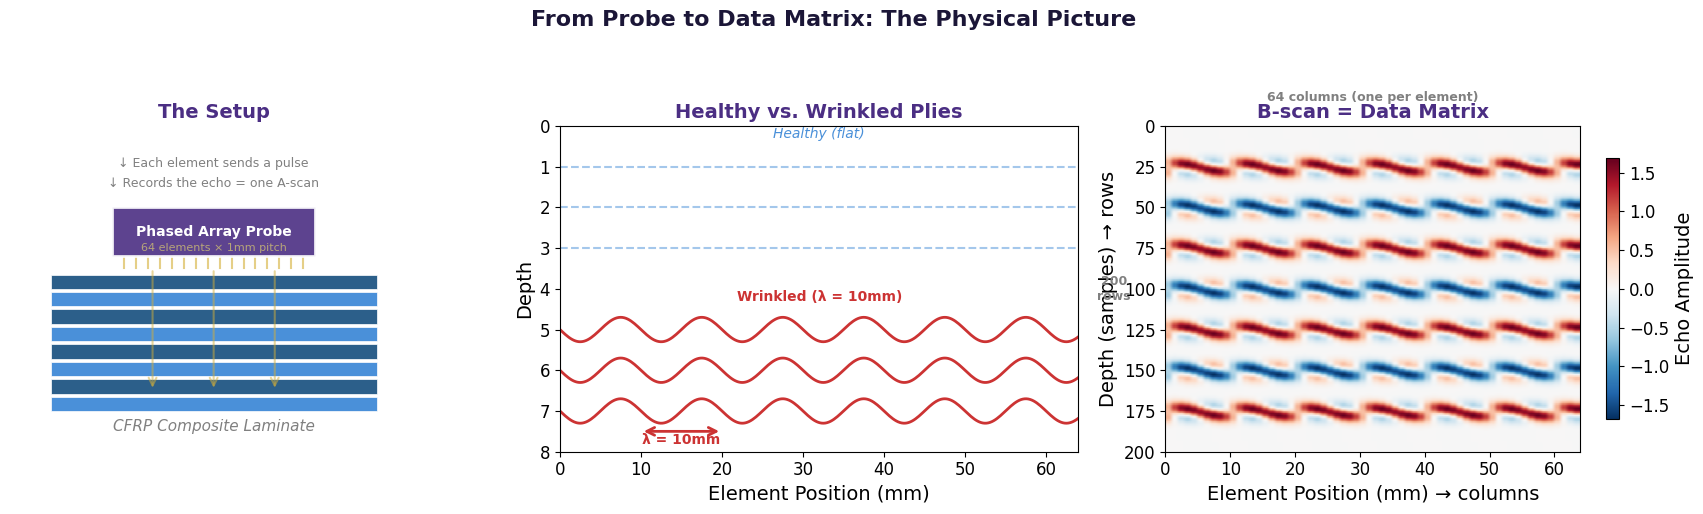

LEFT:   64 ultrasound elements fire into the composite, each recording an A-scan.
MIDDLE: Healthy plies are flat. Wrinkled plies oscillate with wavelength λ.
RIGHT:  Stack all 64 A-scans side by side → a 200×64 matrix (the B-scan).

Our goal: Given only the B-scan matrix, can we automatically
detect the wrinkle and measure its wavelength λ?

Spoiler: PCA can't do it. DMD can. Let's see why.


In [ ]:
# ── Visual intro: physical setup diagram ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Probe + Laminate schematic
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('The Setup', fontsize=14, fontweight='bold', color=UW_PURPLE)

# Draw composite laminate (layered rectangle)
for i, y in enumerate(np.linspace(1, 4, 8)):
    color = '#4a90d9' if i % 2 == 0 else '#2c5f8a'
    ax.add_patch(plt.Rectangle((1, y), 8, 0.35, facecolor=color, edgecolor='white', linewidth=0.5))
ax.text(5, 0.5, 'CFRP Composite Laminate', ha='center', fontsize=11, style='italic', color='gray')

# Draw probe on top
ax.add_patch(plt.Rectangle((2.5, 4.8), 5, 1.2, facecolor=UW_PURPLE, edgecolor='white', linewidth=2,
                             alpha=0.9, zorder=5))
ax.text(5, 5.4, 'Phased Array Probe', ha='center', va='center', fontsize=10,
        fontweight='bold', color='white', zorder=6)
ax.text(5, 5.0, '64 elements × 1mm pitch', ha='center', va='center', fontsize=8,
        color=UW_GOLD, zorder=6)

# Draw element lines
for x in np.linspace(2.8, 7.2, 16):
    ax.plot([x, x], [4.8, 4.5], color=ACCENT_GOLD, linewidth=1.5, alpha=0.6)

# Arrows showing ultrasound pulses
for x in [3.5, 5.0, 6.5]:
    ax.annotate('', xy=(x, 1.5), xytext=(x, 4.5),
                arrowprops=dict(arrowstyle='->', color=ACCENT_GOLD, lw=1.5, alpha=0.5))

ax.text(5, 7.0, '↓ Each element sends a pulse', ha='center', fontsize=9, color='gray')
ax.text(5, 6.5, '↓ Records the echo = one A-scan', ha='center', fontsize=9, color='gray')

# Panel 2: Healthy vs Wrinkled cross-section
ax2 = axes[1]
x_cross = np.linspace(0, 64, 300)
ax2.set_xlim(0, 64)
ax2.set_ylim(0, 8)
ax2.set_title('Healthy vs. Wrinkled Plies', fontsize=14, fontweight='bold', color=UW_PURPLE)
ax2.set_xlabel('Element Position (mm)')
ax2.set_ylabel('Depth')
ax2.invert_yaxis()

# Healthy plies (top half, dashed)
for i, y_base in enumerate([1.0, 2.0, 3.0]):
    ax2.plot(x_cross, np.ones_like(x_cross) * y_base, '--', color='#4a90d9',
             linewidth=1.5, alpha=0.5)
ax2.text(32, 0.3, 'Healthy (flat)', ha='center', fontsize=10, color='#4a90d9', style='italic')

# Wrinkled plies (bottom half, solid with sinusoidal shape)
wrinkle_lambda = 10  # wavelength in mm
for i, y_base in enumerate([5.0, 6.0, 7.0]):
    y_wrinkled = y_base + 0.3 * np.sin(2 * np.pi * x_cross / wrinkle_lambda)
    ax2.plot(x_cross, y_wrinkled, '-', color='#CC3333', linewidth=2)
ax2.text(32, 4.3, 'Wrinkled (λ = 10mm)', ha='center', fontsize=10, color='#CC3333',
         fontweight='bold')

# Annotate wavelength
ax2.annotate('', xy=(10, 7.5), xytext=(20, 7.5),
            arrowprops=dict(arrowstyle='<->', color='#CC3333', lw=2))
ax2.text(15, 7.8, 'λ = 10mm', ha='center', fontsize=10, color='#CC3333', fontweight='bold')

# Panel 3: B-scan = data matrix
ax3 = axes[2]
# Generate a quick B-scan preview (need numpy which is already imported at top of notebook)
depth = np.arange(200)
ply_pos = np.linspace(25, 175, 7)
base = np.zeros(200)
for pi, pp in enumerate(ply_pos):
    pol = 1 if pi % 2 == 0 else -1
    base += pol * np.exp(-0.5 * ((depth - pp) / 3.0) ** 2)
mode_d = np.gradient(base)
mode_c = np.gradient(mode_d)

X_preview = np.zeros((200, 64))
for j in range(64):
    X_preview[:, j] = base + 5.0 * (np.sin(2*np.pi*j/10)*mode_d + np.cos(2*np.pi*j/10)*mode_c)

im = ax3.imshow(X_preview, aspect='auto', cmap='RdBu_r', origin='upper',
                 extent=[0, 64, 200, 0])
ax3.set_title('B-scan = Data Matrix', fontsize=14, fontweight='bold', color=UW_PURPLE)
ax3.set_xlabel('Element Position (mm) → columns')
ax3.set_ylabel('Depth (samples) → rows')
plt.colorbar(im, ax=ax3, shrink=0.8, label='Echo Amplitude')

# Annotate matrix dimensions
ax3.text(32, -15, '64 columns (one per element)', ha='center', fontsize=9, color='gray',
         fontweight='bold')
ax3.text(-8, 100, '200\nrows', ha='center', va='center', fontsize=9, color='gray',
         fontweight='bold', rotation=0)

plt.suptitle('From Probe to Data Matrix: The Physical Picture',
             fontsize=16, fontweight='bold', y=1.03, color=UW_DARK)
plt.tight_layout()
plt.show()

print('LEFT:   64 ultrasound elements fire into the composite, each recording an A-scan.')
print('MIDDLE: Healthy plies are flat. Wrinkled plies oscillate with wavelength λ.')
print('RIGHT:  Stack all 64 A-scans side by side → a 200×64 matrix (the B-scan).')
print()
print('Our goal: Given only the B-scan matrix, can we automatically')
print('detect the wrinkle and measure its wavelength λ?')
print()
print('Spoiler: PCA can\'t do it. DMD can. Let\'s see why.')

---
### Matrix Diagrams: SVD vs PCA vs DMD

Before we look at the code, here's a visual overview of what each method actually does with the matrices. Each colored box is a matrix, with its dimensions labeled below. This makes it easy to track what's happening at every step.

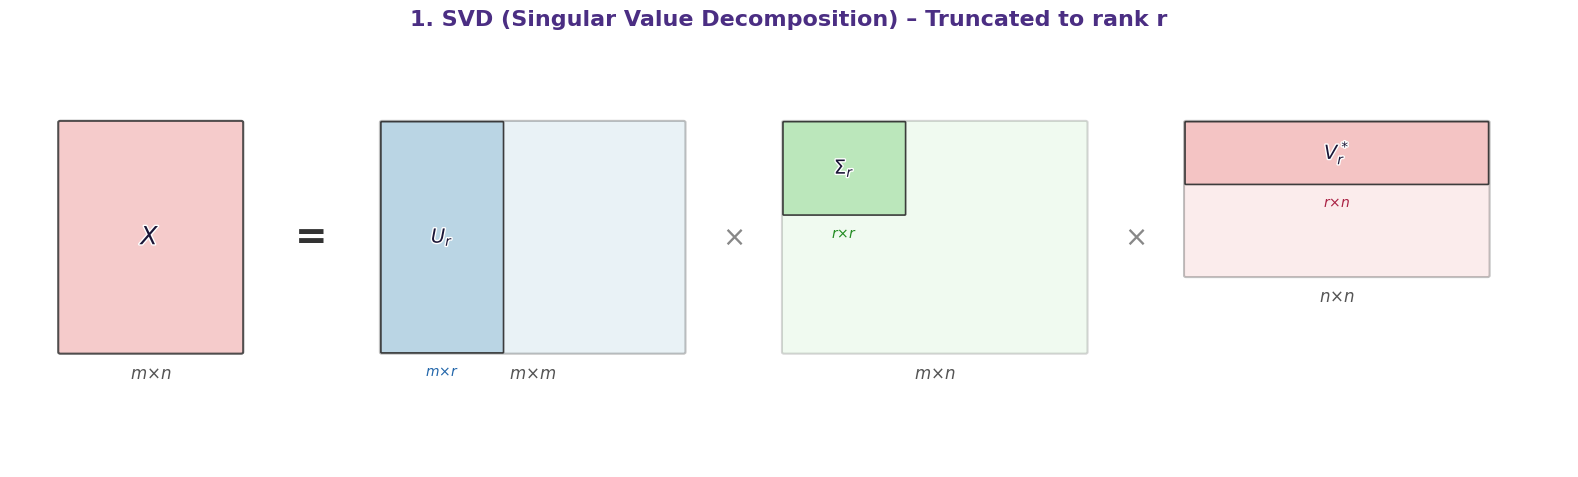

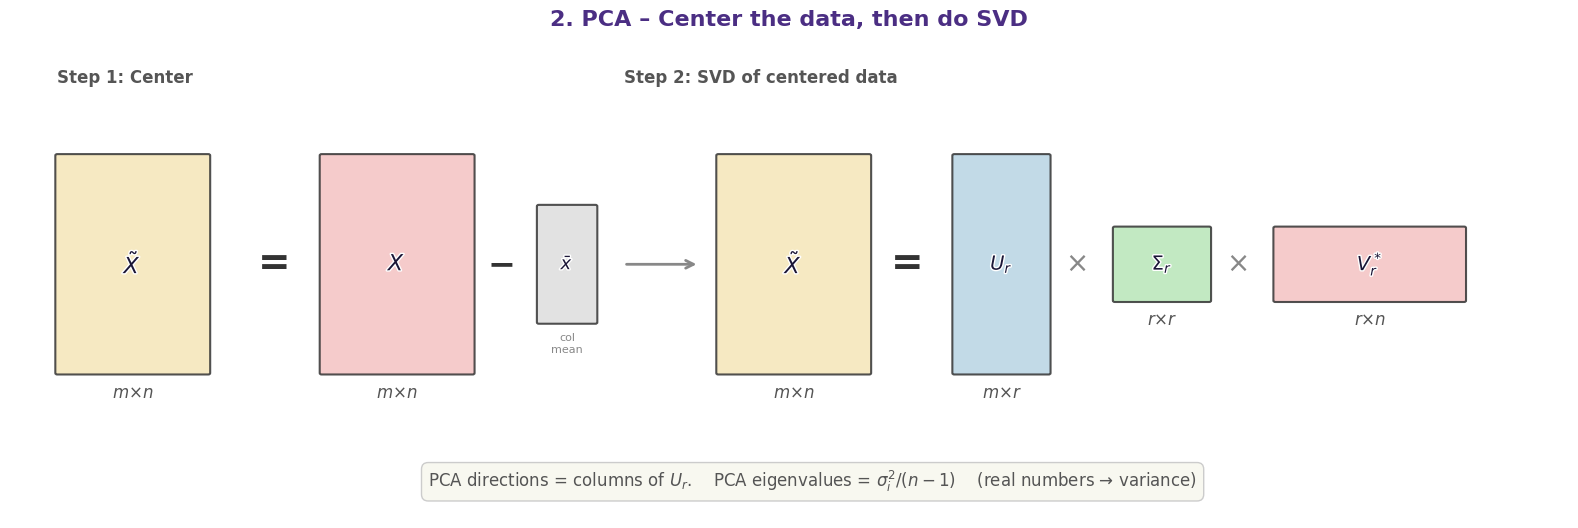

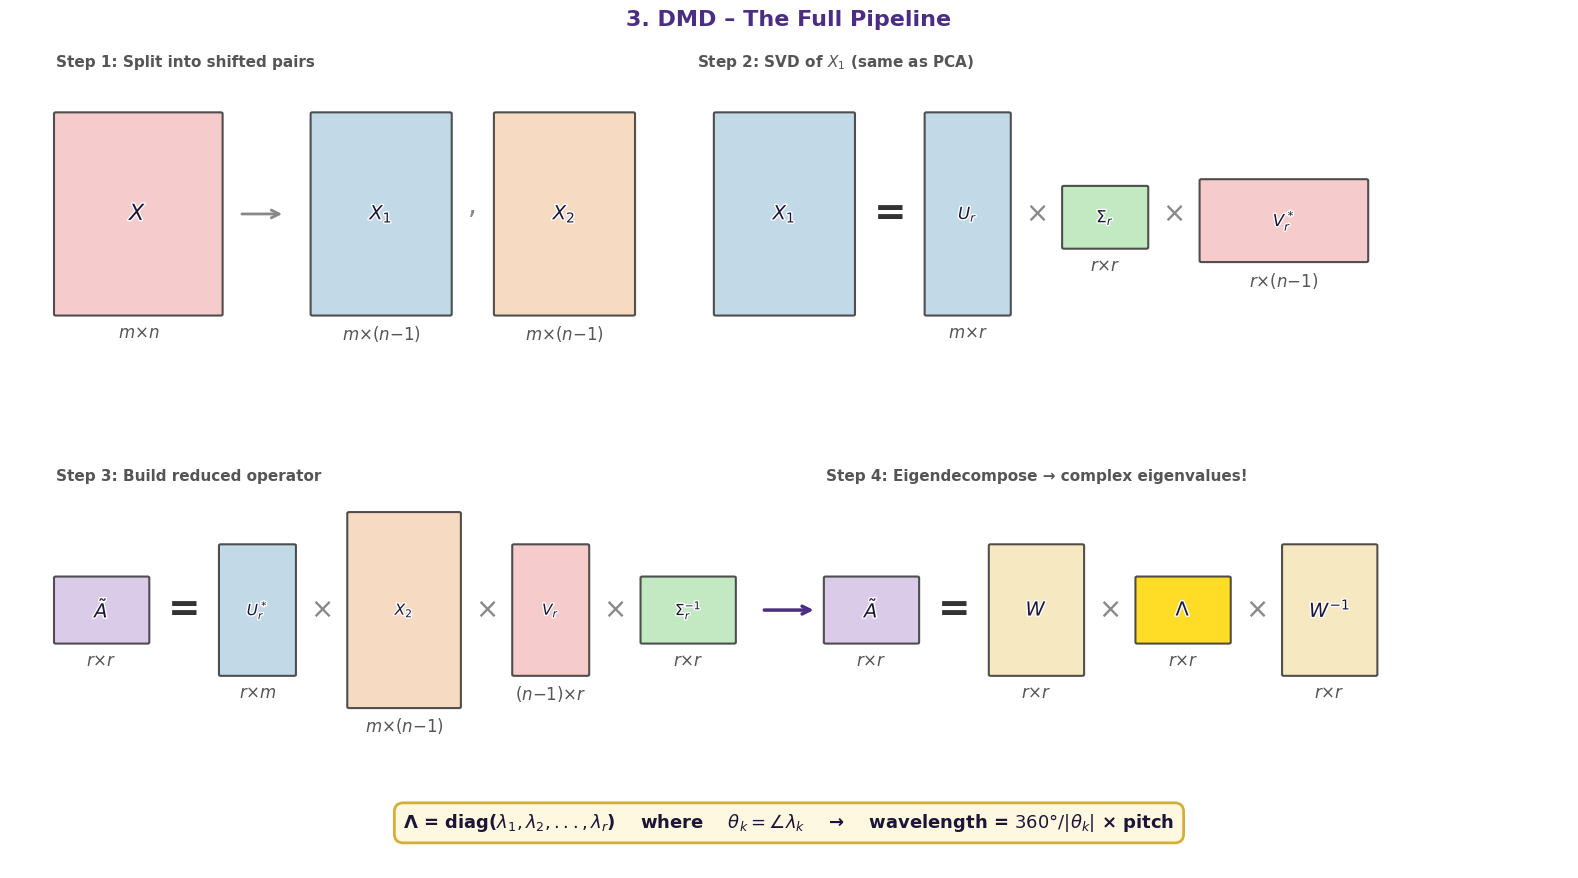

These diagrams show the shape of every matrix at each step.
Notice how DMD starts with the same SVD that PCA uses,
then adds Steps 3-4 to get complex eigenvalues (= frequencies).


In [ ]:
# Matrix box diagrams: SVD, PCA, and DMD at a glance
# Shows the shape of every matrix so you can see exactly what's happening

from matplotlib.patches import FancyBboxPatch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

def draw_matrix_box(ax, x, y, w, h, label, dims, color, alpha=0.85,
                    fontsize=16, dimsize=12, highlight_region=None, highlight_color=None,
                    highlight_label=None, highlight_dimsize=10):
    """Draw a labeled matrix box with optional highlighted sub-region."""
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02",
                          facecolor=color, edgecolor='#333333', linewidth=1.5, alpha=alpha)
    ax.add_patch(box)

    # Highlight sub-region (for showing truncated part)
    if highlight_region:
        hx, hy, hw, hh = highlight_region
        hbox = FancyBboxPatch((hx, hy), hw, hh, boxstyle="round,pad=0.01",
                               facecolor=highlight_color, edgecolor='#333333',
                               linewidth=1.2, alpha=0.95)
        ax.add_patch(hbox)
        if highlight_label:
            ax.text(hx + hw/2, hy + hh/2, highlight_label, ha='center', va='center',
                    fontsize=fontsize-2, fontweight='bold', color='#1B1637',
                    path_effects=[pe.withStroke(linewidth=2, foreground='white')])

    # Main label
    lx = x + w/2
    if highlight_region:
        # Place main label below the highlight if there is one
        ly = y + h * 0.3
    else:
        ly = y + h/2
    ax.text(lx, ly, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='#1B1637',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

    # Dimensions below
    ax.text(x + w/2, y - 0.15, dims, ha='center', va='top',
            fontsize=dimsize, color='#555555', style='italic')


def draw_equals(ax, x, y, fontsize=28):
    ax.text(x, y, '=', ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color='#333333')


def draw_times(ax, x, y, fontsize=20):
    ax.text(x, y, '×', ha='center', va='center', fontsize=fontsize,
            color='#888888')


# ─── Colors ───
PINK = '#F4C2C2'
BLUE = '#B8D4E3'
GREEN = '#B8E6B8'
GOLD_LIGHT = '#F5E6B8'
PURPLE_LIGHT = '#D4C2E6'
ORANGE_LIGHT = '#F5D4B8'


# ═══════════════════════════════════════════
# FIGURE 1: SVD (Truncated)
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 5))
ax.set_xlim(-0.5, 15)
ax.set_ylim(-1, 4.5)
ax.axis('off')
ax.set_title('1. SVD (Singular Value Decomposition) – Truncated to rank r',
             fontsize=16, fontweight='bold', color=UW_PURPLE, pad=15)

# X = U_r Σ_r V_r*
# X: m×n
draw_matrix_box(ax, 0, 0.5, 1.8, 3.0, '$X$', '$m × n$', PINK, fontsize=18)

draw_equals(ax, 2.5, 2.0)

# U full (faded) with U_r highlighted
draw_matrix_box(ax, 3.2, 0.5, 3.0, 3.0, '', '$m × m$', BLUE, alpha=0.3)
# U_r highlighted region
draw_matrix_box(ax, 3.2, 0.5, 1.2, 3.0, '', '', BLUE, alpha=0.0,
                highlight_region=(3.2, 0.5, 1.2, 3.0),
                highlight_color=BLUE, highlight_label='$U_r$')
ax.text(3.2 + 1.2/2, 0.35, '$m × r$', ha='center', va='top',
        fontsize=10, color='#2266AA', style='italic', fontweight='bold')

draw_times(ax, 6.7, 2.0)

# Σ full (faded) with Σ_r highlighted
draw_matrix_box(ax, 7.2, 0.5, 3.0, 3.0, '', '$m × n$', GREEN, alpha=0.2)
# Σ_r highlighted (small square top-left)
draw_matrix_box(ax, 7.2, 2.3, 1.2, 1.2, '', '', GREEN, alpha=0.0,
                highlight_region=(7.2, 2.3, 1.2, 1.2),
                highlight_color=GREEN, highlight_label='$Σ_r$')
ax.text(7.2 + 1.2/2, 2.15, '$r × r$', ha='center', va='top',
        fontsize=10, color='#228B22', style='italic', fontweight='bold')

draw_times(ax, 10.7, 2.0)

# V* full (faded) with V_r* highlighted
draw_matrix_box(ax, 11.2, 1.5, 3.0, 2.0, '', '$n × n$', PINK, alpha=0.3)
# V_r* highlighted (top strip)
draw_matrix_box(ax, 11.2, 2.7, 3.0, 0.8, '', '', PINK, alpha=0.0,
                highlight_region=(11.2, 2.7, 3.0, 0.8),
                highlight_color=PINK, highlight_label='$V_r^*$')
ax.text(11.2 + 3.0/2, 2.55, '$r × n$', ha='center', va='top',
        fontsize=10, color='#AA2244', style='italic', fontweight='bold')

plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════
# FIGURE 2: PCA
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 5.5))
ax.set_xlim(-0.5, 16)
ax.set_ylim(-1.5, 5)
ax.axis('off')
ax.set_title('2. PCA – Center the data, then do SVD',
             fontsize=16, fontweight='bold', color=UW_PURPLE, pad=15)

# Step annotation
ax.text(0, 4.5, 'Step 1: Center', fontsize=12, color='#555', fontweight='bold')
ax.text(6, 4.5, 'Step 2: SVD of centered data', fontsize=12, color='#555', fontweight='bold')

# X_centered = X - mean
draw_matrix_box(ax, 0, 0.5, 1.6, 3.0, '$\\tilde{X}$', '$m × n$', GOLD_LIGHT, fontsize=16)
draw_equals(ax, 2.3, 2.0)
draw_matrix_box(ax, 2.8, 0.5, 1.6, 3.0, '$X$', '$m × n$', PINK, fontsize=16)
ax.text(4.7, 2.0, '−', ha='center', va='center', fontsize=24, fontweight='bold', color='#333')
draw_matrix_box(ax, 5.1, 1.2, 0.6, 1.6, '$\\bar{x}$', '', '#DDD', fontsize=13)
ax.text(5.4, 1.05, 'col\nmean', ha='center', va='top', fontsize=8, color='#888')

# Arrow
ax.annotate('', xy=(6.8, 2.0), xytext=(6.0, 2.0),
            arrowprops=dict(arrowstyle='->', lw=2, color='#888'))

# SVD part
draw_matrix_box(ax, 7, 0.5, 1.6, 3.0, '$\\tilde{X}$', '$m × n$', GOLD_LIGHT, fontsize=16)
draw_equals(ax, 9.0, 2.0)

# U_r
draw_matrix_box(ax, 9.5, 0.5, 1.0, 3.0, '$U_r$', '$m × r$', BLUE, fontsize=14)
draw_times(ax, 10.8, 2.0)
# Σ_r
draw_matrix_box(ax, 11.2, 1.5, 1.0, 1.0, '$Σ_r$', '$r × r$', GREEN, fontsize=14)
draw_times(ax, 12.5, 2.0)
# V_r*
draw_matrix_box(ax, 12.9, 1.5, 2.0, 1.0, '$V_r^*$', '$r × n$', PINK, fontsize=14)

# Bottom note
ax.text(8, -1.0, 'PCA directions = columns of $U_r$.    PCA eigenvalues = $σ_i^2 / (n-1)$    (real numbers → variance)',
        ha='center', va='center', fontsize=12, color='#555',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F8F8F0', edgecolor='#CCC'))

plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════
# FIGURE 3: DMD (Full Pipeline)
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [1, 1.1]})

# --- Top row: Form X1, X2 and do SVD ---
ax = axes[0]
ax.set_xlim(-0.5, 16.5)
ax.set_ylim(-1.2, 4.5)
ax.axis('off')
ax.set_title('3. DMD – The Full Pipeline',
             fontsize=16, fontweight='bold', color=UW_PURPLE, pad=15)

# Step 1 label
ax.text(0, 4.2, 'Step 1: Split into shifted pairs', fontsize=11, color='#555', fontweight='bold')

# X with vertical split shown
draw_matrix_box(ax, 0, 0.5, 1.8, 3.0, '$X$', '$m × n$', PINK, fontsize=16)
ax.annotate('', xy=(2.5, 2.0), xytext=(2.0, 2.0),
            arrowprops=dict(arrowstyle='->', lw=2, color='#888'))

# X1 and X2
draw_matrix_box(ax, 2.8, 0.5, 1.5, 3.0, '$X_1$', '$m × (n{-}1)$', '#B8D4E3', fontsize=14)
ax.text(4.5, 2.0, ',', fontsize=20, color='#888')
draw_matrix_box(ax, 4.8, 0.5, 1.5, 3.0, '$X_2$', '$m × (n{-}1)$', '#F5D4B8', fontsize=14)

# Step 2 label
ax.text(7, 4.2, 'Step 2: SVD of $X_1$ (same as PCA)', fontsize=11, color='#555', fontweight='bold')

# SVD of X1
draw_matrix_box(ax, 7.2, 0.5, 1.5, 3.0, '$X_1$', '', '#B8D4E3', fontsize=14)
draw_equals(ax, 9.1, 2.0)
draw_matrix_box(ax, 9.5, 0.5, 0.9, 3.0, '$U_r$', '$m × r$', BLUE, fontsize=12)
draw_times(ax, 10.7, 2.0)
draw_matrix_box(ax, 11.0, 1.5, 0.9, 0.9, '$Σ_r$', '$r × r$', GREEN, fontsize=12)
draw_times(ax, 12.2, 2.0)
draw_matrix_box(ax, 12.5, 1.3, 1.8, 1.2, '$V_r^*$', '$r × (n{-}1)$', PINK, fontsize=12)

# --- Bottom row: Build Ã, eigendecompose ---
ax2 = axes[1]
ax2.set_xlim(-0.5, 16.5)
ax2.set_ylim(-1.5, 5)
ax2.axis('off')

# Step 3 label
ax2.text(0, 4.5, 'Step 3: Build reduced operator', fontsize=11, color='#555', fontweight='bold')

# Ã = U_r* X2 V_r Σ_r^{-1}
draw_matrix_box(ax2, 0, 2.0, 1.0, 1.0, '$\\tilde{A}$', '$r × r$', PURPLE_LIGHT, fontsize=14)
draw_equals(ax2, 1.4, 2.5)
draw_matrix_box(ax2, 1.8, 1.5, 0.8, 2.0, '$U_r^*$', '$r × m$', BLUE, fontsize=11)
draw_times(ax2, 2.9, 2.5)
draw_matrix_box(ax2, 3.2, 1.0, 1.2, 3.0, '$X_2$', '$m × (n{-}1)$', ORANGE_LIGHT, fontsize=11)
draw_times(ax2, 4.7, 2.5)
draw_matrix_box(ax2, 5.0, 1.5, 0.8, 2.0, '$V_r$', '$(n{-}1) × r$', PINK, fontsize=11)
draw_times(ax2, 6.1, 2.5)
draw_matrix_box(ax2, 6.4, 2.0, 1.0, 1.0, '$Σ_r^{-1}$', '$r × r$', GREEN, fontsize=11)

# Arrow to step 4
ax2.annotate('', xy=(8.3, 2.5), xytext=(7.7, 2.5),
            arrowprops=dict(arrowstyle='->', lw=2.5, color=UW_PURPLE))

# Step 4 label
ax2.text(8.4, 4.5, 'Step 4: Eigendecompose → complex eigenvalues!', fontsize=11, color='#555', fontweight='bold')

# Ã = W Λ W^{-1}
draw_matrix_box(ax2, 8.4, 2.0, 1.0, 1.0, '$\\tilde{A}$', '$r × r$', PURPLE_LIGHT, fontsize=14)
draw_equals(ax2, 9.8, 2.5)
draw_matrix_box(ax2, 10.2, 1.5, 1.0, 2.0, '$W$', '$r × r$', GOLD_LIGHT, fontsize=14)
draw_times(ax2, 11.5, 2.5)
draw_matrix_box(ax2, 11.8, 2.0, 1.0, 1.0, '$Λ$', '$r × r$', '#FFD700', fontsize=14)
draw_times(ax2, 13.1, 2.5)
draw_matrix_box(ax2, 13.4, 1.5, 1.0, 2.0, '$W^{-1}$', '$r × r$', GOLD_LIGHT, fontsize=14)

# Bottom annotation: what the eigenvalues tell you
ax2.text(8, -0.8,
         'Λ = diag($λ_1, λ_2, ..., λ_r$)    where    $θ_k = ∠λ_k$    →    wavelength = $360° / |θ_k|$ × pitch',
         ha='center', va='center', fontsize=13, color=UW_DARK, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8E1', edgecolor=ACCENT_GOLD, linewidth=2))

plt.tight_layout()
plt.show()

print('These diagrams show the shape of every matrix at each step.')
print('Notice how DMD starts with the same SVD that PCA uses,')
print('then adds Steps 3-4 to get complex eigenvalues (= frequencies).')

---
## Cell 1: Warm-Up: DMD on a Simple Oscillation

Before touching ultrasound data, let's build intuition with the simplest possible example.

**Setup:** A point rotates around a circle, completing one full loop every 10 columns. To describe its position at column `j`, we need two coordinates:
- Column `j` = `[sin(2πj/10), cos(2πj/10)]`

This is a **complex exponential** (e^(iθ)), stored as a 2×64 real matrix. It's one oscillation at one frequency, described by two coordinates per column.

**Question:** Can DMD recover the oscillation frequency θ = 360°/10 = 36°?

Data shape: (2, 64)  (2 rows × 64 columns)
Column 0: [0.000, 1.000]
Column 1: [0.588, 0.809]
Column 2: [0.951, 0.309]



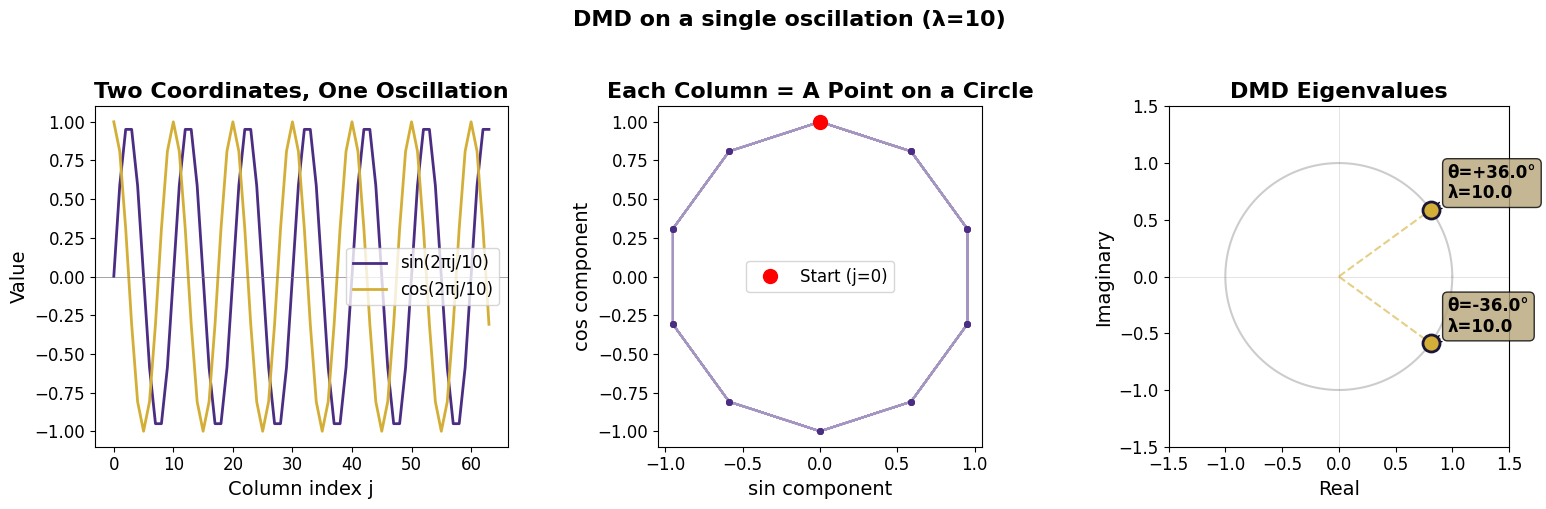

Expected: θ = ±36° (because 360°/10 = 36°)

  DMD eigenvalue: +0.8090 +0.5878j  →  θ = +36.0°  |λ| = 1.0000
  DMD eigenvalue: +0.8090 -0.5878j  →  θ = -36.0°  |λ| = 1.0000

✓ DMD found θ = ±36° — exactly the oscillation frequency!
  The conjugate pair (±θ) always appears together because our data is real-valued.

KEY INSIGHT:
  The ANGLE on the unit circle tells you the oscillation frequency.
  θ = 36° means "the pattern repeats every 360/36 = 10 columns."


In [ ]:
# The simplest DMD example: a rotating complex exponential
n_cols = 64
wavelength = 10  # the signal repeats every 10 columns

# Build data: each column j = [sin(2πj/λ), cos(2πj/λ)]
j = np.arange(n_cols)
X_simple = np.vstack([
    np.sin(2 * np.pi * j / wavelength),
    np.cos(2 * np.pi * j / wavelength)
])

print(f'Data shape: {X_simple.shape}  (2 rows × {n_cols} columns)')
print(f'Column 0: [{X_simple[0,0]:.3f}, {X_simple[1,0]:.3f}]')
print(f'Column 1: [{X_simple[0,1]:.3f}, {X_simple[1,1]:.3f}]')
print(f'Column 2: [{X_simple[0,2]:.3f}, {X_simple[1,2]:.3f}]')
print()

# ── Run DMD ──
eigenvalues_simple, modes_simple, sv_simple = run_dmd(X_simple, r=2)

# ── Visualize ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: The raw signal
axes[0].plot(j, X_simple[0, :], color=UW_PURPLE, linewidth=2, label='sin(2πj/10)')
axes[0].plot(j, X_simple[1, :], color=ACCENT_GOLD, linewidth=2, label='cos(2πj/10)')
axes[0].set_xlabel('Column index j')
axes[0].set_ylabel('Value')
axes[0].set_title('Two Coordinates, One Oscillation', fontweight='bold')
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)

# Panel 2: The 2D trajectory (each column is a point)
axes[1].plot(X_simple[0, :], X_simple[1, :], 'o-', color=UW_PURPLE,
             markersize=4, alpha=0.5)
axes[1].plot(X_simple[0, 0], X_simple[1, 0], 'o', color='red',
             markersize=10, zorder=10, label='Start (j=0)')
axes[1].set_xlabel('sin component')
axes[1].set_ylabel('cos component')
axes[1].set_title('Each Column = A Point on a Circle', fontweight='bold')
axes[1].set_aspect('equal')
axes[1].legend()

# Panel 3: DMD eigenvalues on unit circle
theta_c = np.linspace(0, 2*np.pi, 200)
axes[2].plot(np.cos(theta_c), np.sin(theta_c), 'k-', alpha=0.2)
axes[2].axhline(0, color='gray', linewidth=0.5, alpha=0.3)
axes[2].axvline(0, color='gray', linewidth=0.5, alpha=0.3)

for ev in eigenvalues_simple:
    ang = np.angle(ev, deg=True)
    axes[2].scatter(ev.real, ev.imag, c=ACCENT_GOLD, s=150,
                    edgecolors=UW_DARK, linewidth=2, zorder=10)
    axes[2].plot([0, ev.real], [0, ev.imag], '--', color=ACCENT_GOLD, alpha=0.6)
    wl = 360.0 / abs(ang) if abs(ang) > 0.5 else float('inf')
    label = f'θ={ang:+.1f}°\nλ={wl:.1f}'
    axes[2].annotate(label, (ev.real, ev.imag),
                     xytext=(ev.real + 0.15, ev.imag + 0.1),
                     fontsize=12, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor=UW_GOLD, alpha=0.8),
                     arrowprops=dict(arrowstyle='->'))

axes[2].set_xlim(-1.5, 1.5)
axes[2].set_ylim(-1.5, 1.5)
axes[2].set_aspect('equal')
axes[2].set_title('DMD Eigenvalues', fontweight='bold')
axes[2].set_xlabel('Real')
axes[2].set_ylabel('Imaginary')

plt.suptitle(f'DMD on a single oscillation (λ={wavelength})',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print results
print(f'Expected: θ = ±{360/wavelength:.0f}° (because 360°/{wavelength} = {360/wavelength:.0f}°)')
print()
for ev in eigenvalues_simple:
    ang = np.angle(ev, deg=True)
    print(f'  DMD eigenvalue: {ev.real:+.4f} {ev.imag:+.4f}j  →  θ = {ang:+.1f}°  |λ| = {abs(ev):.4f}')
print()
print('✓ DMD found θ = ±36° — exactly the oscillation frequency!')
print('  The conjugate pair (±θ) always appears together because our data is real-valued.')
print()
print('KEY INSIGHT:')
print('  The ANGLE on the unit circle tells you the oscillation frequency.')
print('  θ = 36° means "the pattern repeats every 360/36 = 10 columns."')

---
## Cell 2: Change the Wavelength, Watch the Eigenvalue Move

Let's run DMD on oscillations with different wavelengths and see how the eigenvalue angle changes.

**Prediction:** wavelength λ → eigenvalue angle θ = 360°/λ
- λ = 5 → θ = 72°
- λ = 10 → θ = 36°  
- λ = 20 → θ = 18°
- λ = 32 → θ = 11.25°

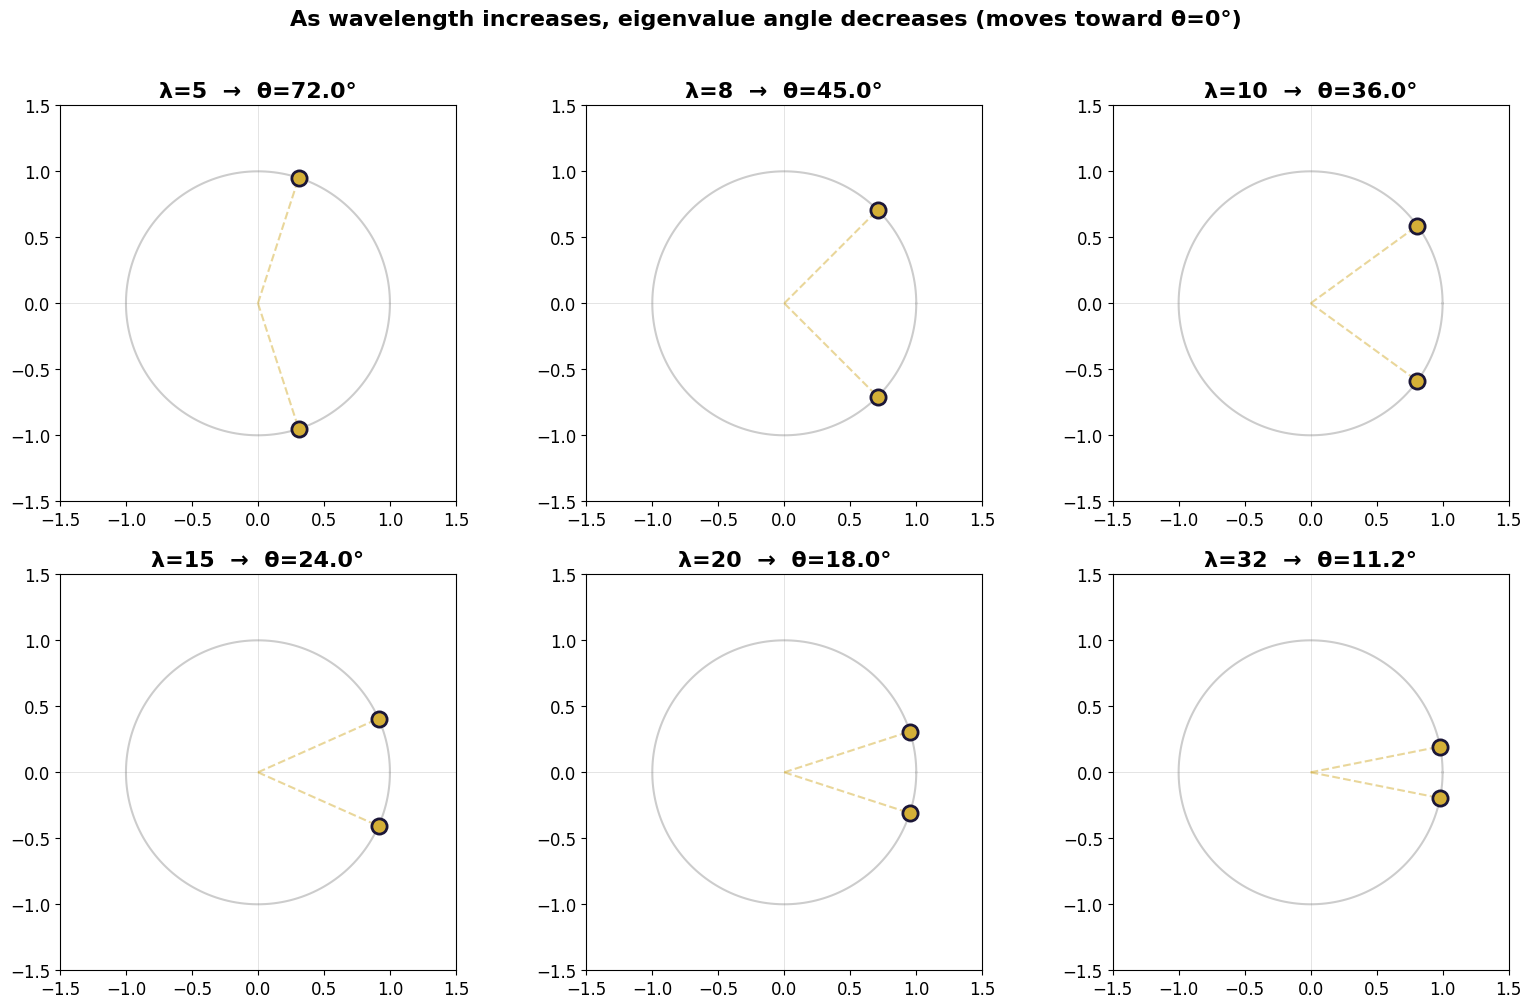

 λ (wavelength)    Expected θ    Detected θ    Match?
───────────────────────────────────────────────────────
              5          72.0°          72.0°         ✓
              8          45.0°          45.0°         ✓
             10          36.0°          36.0°         ✓
             15          24.0°          24.0°         ✓
             20          18.0°          18.0°         ✓
             32          11.2°          11.2°         ✓

The formula θ = 360°/λ works perfectly for all wavelengths!


In [ ]:
# Try several wavelengths and verify the formula θ = 360°/λ
test_wavelengths = [5, 8, 10, 15, 20, 32]
n_cols = 64

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
results = []

for idx, wl in enumerate(test_wavelengths):
    ax = axes[idx // 3, idx % 3]

    # Generate simple oscillation
    j = np.arange(n_cols)
    X_test = np.vstack([np.sin(2*np.pi*j/wl), np.cos(2*np.pi*j/wl)])

    # Run DMD
    evals_test, _, _ = run_dmd(X_test, r=2)

    # Plot on unit circle
    theta_c = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta_c), np.sin(theta_c), 'k-', alpha=0.2)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.3)

    for ev in evals_test:
        ax.scatter(ev.real, ev.imag, c=ACCENT_GOLD, s=120,
                   edgecolors=UW_DARK, linewidth=2, zorder=10)
        ax.plot([0, ev.real], [0, ev.imag], '--', color=ACCENT_GOLD, alpha=0.5)

    detected_angle = np.angle(evals_test[np.argmax(np.angle(evals_test, deg=True))], deg=True)
    expected_angle = 360.0 / wl
    results.append((wl, expected_angle, detected_angle))

    ax.set_title(f'λ={wl}  →  θ={detected_angle:.1f}°', fontweight='bold')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')

plt.suptitle('As wavelength increases, eigenvalue angle decreases (moves toward θ=0°)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary table
print(f'{"λ (wavelength)":>15s}  {"Expected θ":>12s}  {"Detected θ":>12s}  {"Match?":>8s}')
print('─' * 55)
for wl, exp, det in results:
    match = '✓' if abs(exp - det) < 0.1 else '✗'
    print(f'{wl:>15d}  {exp:>12.1f}°  {det:>12.1f}°  {match:>8s}')
print()
print('The formula θ = 360°/λ works perfectly for all wavelengths!')

---
## Cell 3: Scale Up: From Simple Oscillations to Ultrasound B-scans

Now let's apply the same idea to something physical.

**Setup:** A phased array probe has **64 elements** spaced 1mm apart. Each element fires a pulse and records the echo (an **A-scan**, a 200-point depth signal). Stacking all 64 A-scans gives a **B-scan**: a 200×64 matrix.

If the composite has a **wrinkle defect**, the ply layers buckle with wavelength λ across elements. Instead of 2 rows (sin, cos), we now have 200 rows (depth samples). But DMD works exactly the same way: it finds the oscillation frequency across the 64 columns.

**Expected result:** A wrinkle with λ=10mm should give a DMD eigenvalue at θ = 36°, same as the simple oscillation!

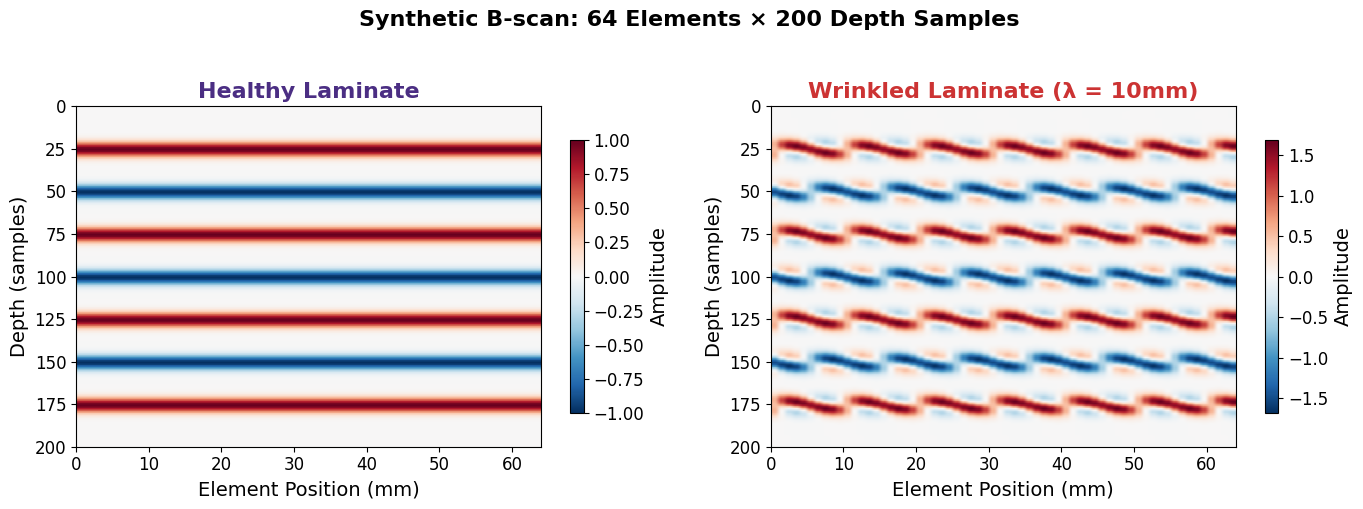

Data matrix shape: (200, 64)  (200 depth samples × 64 elements)
Each COLUMN is one A-scan (echo signal vs. depth).
Each ROW is one depth slice across all 64 elements.

In the wrinkled laminate, you can see the ply bands undulating
with wavelength λ = 10mm (repeating every 10 elements).
Can DMD detect this from the raw matrix?


In [ ]:
# ── Generate synthetic B-scan data ──
X_healthy = generate_bscan(wrinkle_wavelengths=None, noise_level=0.0)
X_wrinkled = generate_bscan(wrinkle_wavelengths=[10], wrinkle_amplitudes=[5.0], noise_level=0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(X_healthy, aspect='auto', cmap='RdBu_r', origin='upper',
                      extent=[0, 64, 200, 0])
axes[0].set_title('Healthy Laminate', fontweight='bold', color=UW_PURPLE)
axes[0].set_xlabel('Element Position (mm)')
axes[0].set_ylabel('Depth (samples)')
plt.colorbar(im0, ax=axes[0], shrink=0.8, label='Amplitude')

im1 = axes[1].imshow(X_wrinkled, aspect='auto', cmap='RdBu_r', origin='upper',
                      extent=[0, 64, 200, 0])
axes[1].set_title('Wrinkled Laminate (λ = 10mm)', fontweight='bold', color='#CC3333')
axes[1].set_xlabel('Element Position (mm)')
axes[1].set_ylabel('Depth (samples)')
plt.colorbar(im1, ax=axes[1], shrink=0.8, label='Amplitude')

plt.suptitle('Synthetic B-scan: 64 Elements × 200 Depth Samples',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Data matrix shape: {X_wrinkled.shape}  (200 depth samples × 64 elements)')
print(f'Each COLUMN is one A-scan (echo signal vs. depth).')
print(f'Each ROW is one depth slice across all 64 elements.')
print()
print('In the wrinkled laminate, you can see the ply bands undulating')
print('with wavelength λ = 10mm (repeating every 10 elements).')
print('Can DMD detect this from the raw matrix?')

---
## Cell 4: PCA Can't Tell You the Frequency

Let's first try PCA on the wrinkled B-scan.

**The shuffle test:** If we randomly reorder the 64 columns, PCA gives the **exact same** singular values. PCA treats columns as an unordered bag; it doesn't know column 5 is next to column 6.

PCA can tell you "there's something interesting happening" (high variance), but it can't tell you the wrinkle's wavelength.

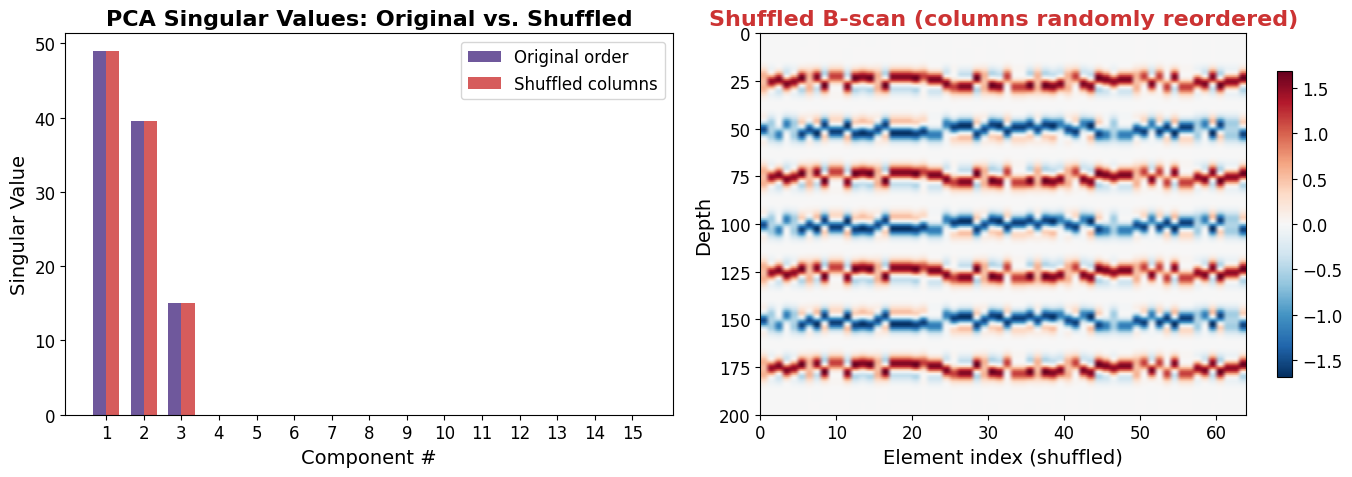

Max difference in singular values after shuffling: 1.42e-14

→ PCA gives IDENTICAL singular values whether columns are ordered or shuffled.
→ It can tell you "there's variance in the data" but NOT the wrinkle wavelength.

This is the fundamental limitation: PCA treats columns as an unordered set.
DMD treats them as a SEQUENCE — and that's where the frequency information lives.


In [ ]:
# ── PCA shuffle test ──
_, S_original, _ = np.linalg.svd(X_wrinkled, full_matrices=False)

# Shuffle columns randomly
rng = np.random.default_rng(123)
X_shuffled = X_wrinkled[:, rng.permutation(64)]
_, S_shuffled, _ = np.linalg.svd(X_shuffled, full_matrices=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot comparison
x_pos = np.arange(1, 16)
width = 0.35
axes[0].bar(x_pos - width/2, S_original[:15], width, color=UW_PURPLE, alpha=0.8, label='Original order')
axes[0].bar(x_pos + width/2, S_shuffled[:15], width, color='#CC3333', alpha=0.8, label='Shuffled columns')
axes[0].set_xlabel('Component #')
axes[0].set_ylabel('Singular Value')
axes[0].set_title('PCA Singular Values: Original vs. Shuffled', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(1, 16))

# Show the shuffled B-scan for visual contrast
im = axes[1].imshow(X_shuffled, aspect='auto', cmap='RdBu_r', origin='upper',
                     extent=[0, 64, 200, 0])
axes[1].set_title('Shuffled B-scan (columns randomly reordered)', fontweight='bold', color='#CC3333')
axes[1].set_xlabel('Element index (shuffled)')
axes[1].set_ylabel('Depth')
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(S_original - S_shuffled))
print(f'Max difference in singular values after shuffling: {max_diff:.2e}')
print()
print('→ PCA gives IDENTICAL singular values whether columns are ordered or shuffled.')
print('→ It can tell you "there\'s variance in the data" but NOT the wrinkle wavelength.')
print()
print('This is the fundamental limitation: PCA treats columns as an unordered set.')
print('DMD treats them as a SEQUENCE — and that\'s where the frequency information lives.')

---
## Cell 5: DMD on the B-scan: Same θ=36° as the Simple Oscillation!

Now let's apply DMD to the wrinkled B-scan. Since the wrinkle has wavelength 10mm, we expect the same θ = 36° we saw with the simple oscillation.

The data is now 200-dimensional instead of 2-dimensional, but the math is identical:
1. Split into X₁ (columns 0–62) and X₂ (columns 1–63)
2. SVD of X₁ (same step PCA uses)
3. Build and eigendecompose the dynamics operator
4. Read off θ from the eigenvalues

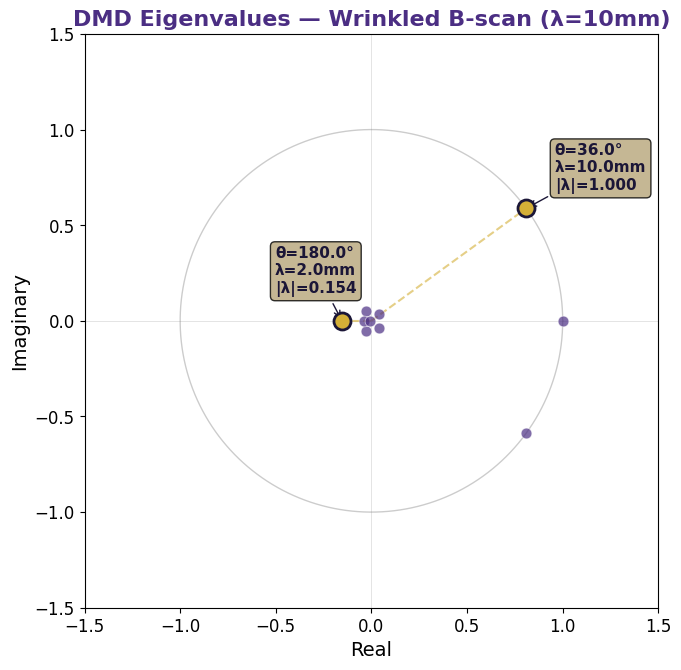

DMD Eigenvalue Analysis:
  θ =   +36.0°  |  |λ| = 1.0000  |  λ = 10.0mm  ← WRINKLE DETECTED!
  θ =   -36.0°  |  |λ| = 1.0000  |  λ = 10.0mm  ← WRINKLE DETECTED!
  θ =  +180.0°  |  |λ| = 0.1541  |  λ = 2.0mm
  θ =  -117.2°  |  |λ| = 0.0594  |  λ = 3.1mm
  θ =  +117.2°  |  |λ| = 0.0594  |  λ = 3.1mm
  θ =   -41.1°  |  |λ| = 0.0532  |  λ = 8.8mm
  θ =   +41.1°  |  |λ| = 0.0532  |  λ = 8.8mm
  θ =  +180.0°  |  |λ| = 0.0385  |  λ = 2.0mm
  θ =  +180.0°  |  |λ| = 0.0095  |  λ = 2.0mm

✓ DMD found θ ≈ ±36° — the wrinkle wavelength of 10mm!
  Same angle as the simple oscillation, because the underlying
  oscillation frequency is the same.

  The 200-dimensional depth information rides along for free —
  the DMD MODES (Φ) capture what the wrinkle looks like in depth,
  while the EIGENVALUES capture how fast it oscillates across elements.


In [ ]:
# DMD on the wrinkled B-scan
eigenvalues, modes, singular_values = run_dmd(X_wrinkled, r=10)

# Plot eigenvalues on the unit circle
plot_unit_circle(eigenvalues,
                 title='DMD Eigenvalues — Wrinkled B-scan (λ=10mm)',
                 annotate_top=2, pitch_mm=1.0)

# Print analysis
print('DMD Eigenvalue Analysis:')
print('=' * 60)
angles = np.angle(eigenvalues, deg=True)
mags = np.abs(eigenvalues)
order = np.argsort(-mags)

for idx in order:
    angle = angles[idx]
    mag = mags[idx]
    if abs(angle) > 1:  # skip DC
        wavelength = 360.0 / abs(angle)
        marker = '  ← WRINKLE DETECTED!' if abs(abs(angle) - 36.0) < 1.0 else ''
        print(f'  θ = {angle:+7.1f}°  |  |λ| = {mag:.4f}  |  '
              f'λ = {wavelength:.1f}mm{marker}')

print()
print('✓ DMD found θ ≈ ±36° — the wrinkle wavelength of 10mm!')
print('  Same angle as the simple oscillation, because the underlying')
print('  oscillation frequency is the same.')
print()
print('  The 200-dimensional depth information rides along for free —')
print('  the DMD MODES (Φ) capture what the wrinkle looks like in depth,')
print('  while the EIGENVALUES capture how fast it oscillates across elements.')

---
### Visual Comparison: What PCA Sees vs. What DMD Sees

Let's put PCA and DMD results side by side on the same B-scan data. PCA gives you variance bars, DMD gives you frequency on the unit circle. Same data, very different answers.

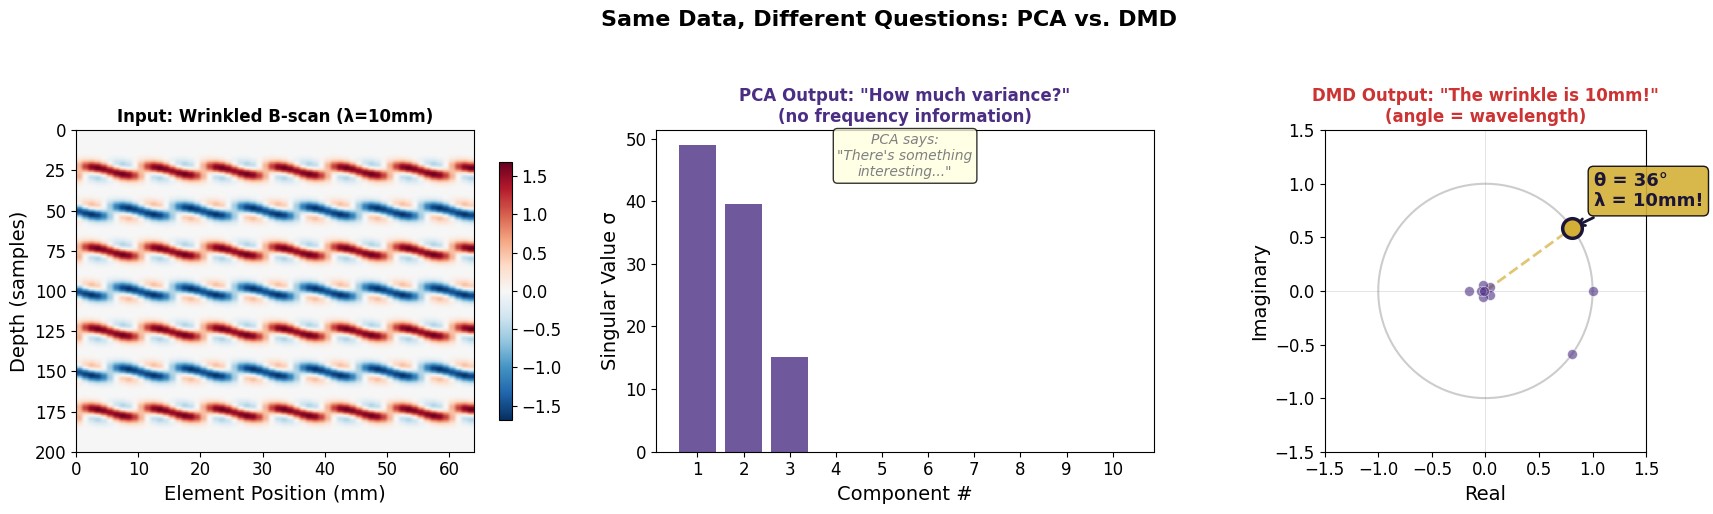

PCA asks: "What directions have the most variance?"  → Real singular values.
DMD asks: "What oscillations connect consecutive columns?" → Complex eigenvalues.

Same SVD step, different question, dramatically different insight!


In [ ]:
# PCA vs DMD: side-by-side visual comparison
fig = plt.figure(figsize=(18, 5))

# Panel 1: The wrinkled B-scan (what we're analyzing)
ax1 = fig.add_subplot(1, 3, 1)
im = ax1.imshow(X_wrinkled, aspect='auto', cmap='RdBu_r', origin='upper', extent=[0, 64, 200, 0])
ax1.set_title('Input: Wrinkled B-scan (λ=10mm)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Element Position (mm)')
ax1.set_ylabel('Depth (samples)')
plt.colorbar(im, ax=ax1, shrink=0.8)

# Panel 2: PCA result (singular values — no frequency info)
ax2 = fig.add_subplot(1, 3, 2)
_, S_pca, _ = np.linalg.svd(X_wrinkled, full_matrices=False)
ax2.bar(range(1, 11), S_pca[:10], color=UW_PURPLE, alpha=0.8)
ax2.set_xlabel('Component #')
ax2.set_ylabel('Singular Value σ')
ax2.set_title('PCA Output: "How much variance?"\n(no frequency information)',
              fontweight='bold', fontsize=12, color=UW_PURPLE)
ax2.set_xticks(range(1, 11))
# Add annotation
ax2.text(5.5, S_pca[0]*0.9, 'PCA says:\n"There\'s something\ninteresting..."',
         ha='center', fontsize=10, style='italic', color='gray',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Panel 3: DMD result (unit circle — frequency detected!)
ax3 = fig.add_subplot(1, 3, 3)
theta_c = np.linspace(0, 2*np.pi, 200)
ax3.plot(np.cos(theta_c), np.sin(theta_c), 'k-', alpha=0.2)
ax3.axhline(0, color='gray', linewidth=0.5, alpha=0.3)
ax3.axvline(0, color='gray', linewidth=0.5, alpha=0.3)

evals_comp, _, _ = run_dmd(X_wrinkled, r=10)
ax3.scatter(evals_comp.real, evals_comp.imag, c=UW_PURPLE, s=50,
            edgecolors='white', linewidth=0.5, zorder=5, alpha=0.6)

# Highlight the wrinkle eigenvalue
angles_comp = np.angle(evals_comp, deg=True)
mags_comp = np.abs(evals_comp)
pos_mask = angles_comp > 1
pos_idx = np.where(pos_mask)[0]
if len(pos_idx) > 0:
    best = pos_idx[np.argmax(mags_comp[pos_idx])]
    ev_best = evals_comp[best]
    ang_best = angles_comp[best]
    ax3.scatter(ev_best.real, ev_best.imag, c=ACCENT_GOLD, s=200,
                edgecolors=UW_DARK, linewidth=2.5, zorder=10)
    ax3.plot([0, ev_best.real], [0, ev_best.imag], '--', color=ACCENT_GOLD, lw=2, alpha=0.7)
    ax3.annotate(f'θ = {ang_best:.0f}°\nλ = {360/ang_best:.0f}mm!',
                 (ev_best.real, ev_best.imag),
                 xytext=(ev_best.real + 0.2, ev_best.imag + 0.2),
                 fontsize=13, fontweight='bold', color=UW_DARK,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor=ACCENT_GOLD, alpha=0.9),
                 arrowprops=dict(arrowstyle='->', color=UW_DARK, lw=2))

ax3.set_xlim(-1.5, 1.5)
ax3.set_ylim(-1.5, 1.5)
ax3.set_aspect('equal')
ax3.set_xlabel('Real')
ax3.set_ylabel('Imaginary')
ax3.set_title('DMD Output: "The wrinkle is 10mm!"\n(angle = wavelength)',
              fontweight='bold', fontsize=12, color='#CC3333')

plt.suptitle('Same Data, Different Questions: PCA vs. DMD',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('PCA asks: "What directions have the most variance?"  → Real singular values.')
print('DMD asks: "What oscillations connect consecutive columns?" → Complex eigenvalues.')
print()
print('Same SVD step, different question, dramatically different insight!')

---
## Cell 6: Inside DMD, Step by Step

Let's walk through DMD step by step to see how it relates to PCA:

1. **Step 2 (SVD of X₁) is the same decomposition PCA uses.** DMD starts with PCA, then goes further.
2. The extra step is building and eigendecomposing the dynamics operator Ã
3. PCA eigenvalues are **real** (variance); DMD eigenvalues are **complex** (frequency)

STEP 1: Form time-shifted pairs
  X₁ shape: (200, 63)  (columns 0 through 62)
  X₂ shape: (200, 63)  (columns 1 through 63)
  Each pair (X₁[:,k], X₂[:,k]) = (element k, element k+1)

STEP 2: SVD of X₁  (same decomposition PCA uses under the hood)
  U: (200, 63)  (spatial modes)
  S: (63,)  (singular values)
  Truncated to r=10 modes

STEP 3: Build reduced dynamics operator Ã
  Ã = Ur* X₂ Vr Σr⁻¹
  Ã shape: (10, 10)  (a small 10×10 matrix!)
  This captures: "given element k, predict element k+1"

STEP 4: Eigendecompose Ã → complex eigenvalues!
  Top eigenvalues:
    λ_1 = +1.0000 +0.0000j  → θ = +0.0°  → wavelength = infmm
    λ_2 = +0.8090 +0.5878j  → θ = +36.0°  → wavelength = 10.0mm
    λ_3 = +0.8090 -0.5878j  → θ = -36.0°  → wavelength = 10.0mm
    λ_4 = -0.1541 +0.0000j  → θ = +180.0°  → wavelength = 2.0mm



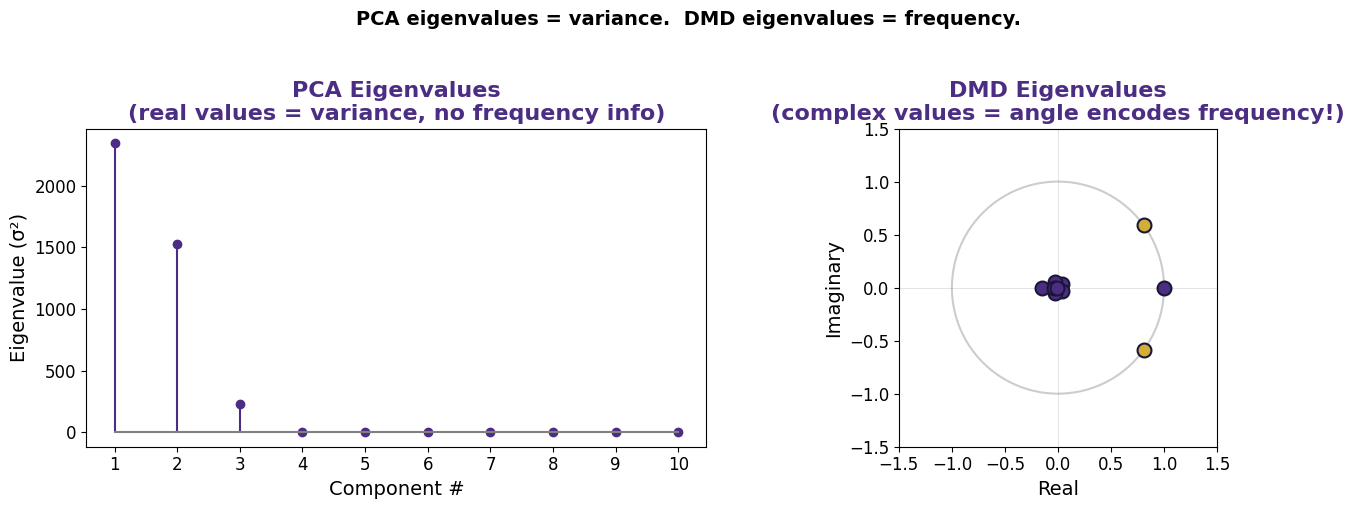

KEY TAKEAWAY:
  PCA eigenvalue σ² = how much variance this mode explains
  DMD eigenvalue angle θ = how fast this mode oscillates across elements
  DMD literally gives you the wrinkle wavelength as a number:
  λ = 360° / θ × pitch = 360° / 36° × 1mm = 10mm ✓


In [ ]:
# Step-by-step DMD walkthrough

# STEP 1: Form time-shifted pairs
X1 = X_wrinkled[:, :-1]   # columns 0..62
X2 = X_wrinkled[:, 1:]    # columns 1..63
print('STEP 1: Form time-shifted pairs')
print(f'  X₁ shape: {X1.shape}  (columns 0 through 62)')
print(f'  X₂ shape: {X2.shape}  (columns 1 through 63)')
print(f'  Each pair (X₁[:,k], X₂[:,k]) = (element k, element k+1)')
print()

# STEP 2: SVD of X1 (same decomposition PCA uses)
U, S, Vh = np.linalg.svd(X1, full_matrices=False)
r = 10
Ur, Sr, Vr = U[:, :r], S[:r], Vh[:r, :].conj().T
print('STEP 2: SVD of X₁  (same decomposition PCA uses under the hood)')
print(f'  U: {U.shape}  (spatial modes)')
print(f'  S: {S.shape}  (singular values)')
print(f'  Truncated to r={r} modes')
print()

# STEP 3: Build reduced operator
A_tilde = Ur.conj().T @ X2 @ Vr @ np.diag(1.0 / Sr)
print('STEP 3: Build reduced dynamics operator Ã')
print(f'  Ã = Ur* X₂ Vr Σr⁻¹')
print(f'  Ã shape: {A_tilde.shape}  (a small {r}×{r} matrix!)')
print(f'  This captures: "given element k, predict element k+1"')
print()

# STEP 4: Eigendecompose
evals_step, W = np.linalg.eig(A_tilde)
print('STEP 4: Eigendecompose Ã → complex eigenvalues!')
print(f'  Top eigenvalues:')
for i in range(min(4, len(evals_step))):
    ev = evals_step[i]
    ang = np.angle(ev, deg=True)
    wl = 360.0 / abs(ang) if abs(ang) > 0.5 else float('inf')
    print(f'    λ_{i+1} = {ev.real:+.4f} {ev.imag:+.4f}j  '
          f'→ θ = {ang:+.1f}°  → wavelength = {wl:.1f}mm')
print()

# COMPARISON: PCA vs DMD eigenvalues
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA eigenvalues (real, on a number line)
axes[0].stem(range(1, r+1), S[:r]**2, linefmt=UW_PURPLE, markerfmt='o', basefmt='gray')
axes[0].set_xlabel('Component #')
axes[0].set_ylabel('Eigenvalue (σ²)')
axes[0].set_title('PCA Eigenvalues\n(real values = variance, no frequency info)', fontweight='bold', color=UW_PURPLE)
axes[0].set_xticks(range(1, r+1))

# DMD eigenvalues (complex, on the unit circle)
theta_c = np.linspace(0, 2*np.pi, 200)
axes[1].plot(np.cos(theta_c), np.sin(theta_c), 'k-', alpha=0.2)
axes[1].axhline(0, color='gray', linewidth=0.5, alpha=0.3)
axes[1].axvline(0, color='gray', linewidth=0.5, alpha=0.3)

for ev in evals_step:
    ang = np.angle(ev, deg=True)
    color = ACCENT_GOLD if abs(abs(ang) - 36) < 2 else UW_PURPLE
    axes[1].scatter(ev.real, ev.imag, c=color, s=100,
                    edgecolors=UW_DARK, linewidth=1.5, zorder=5)

axes[1].set_xlabel('Real')
axes[1].set_ylabel('Imaginary')
axes[1].set_title('DMD Eigenvalues\n(complex values = angle encodes frequency!)', fontweight='bold', color=UW_PURPLE)
axes[1].set_aspect('equal')
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)

plt.suptitle('PCA eigenvalues = variance.  DMD eigenvalues = frequency.',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('KEY TAKEAWAY:')
print('  PCA eigenvalue σ² = how much variance this mode explains')
print('  DMD eigenvalue angle θ = how fast this mode oscillates across elements')
print('  DMD literally gives you the wrinkle wavelength as a number:')
print(f'  λ = 360° / θ × pitch = 360° / 36° × 1mm = 10mm ✓')

---
### How to Choose the Truncation Rank r

In the cells above, we used `r=10` or `r=2`. But how do you pick r in practice?

**Rule of thumb:** Plot the singular values of X₁. Truncate where they drop sharply (the "elbow"). Modes below the elbow are mostly noise; including them adds spurious eigenvalues without improving wrinkle detection.

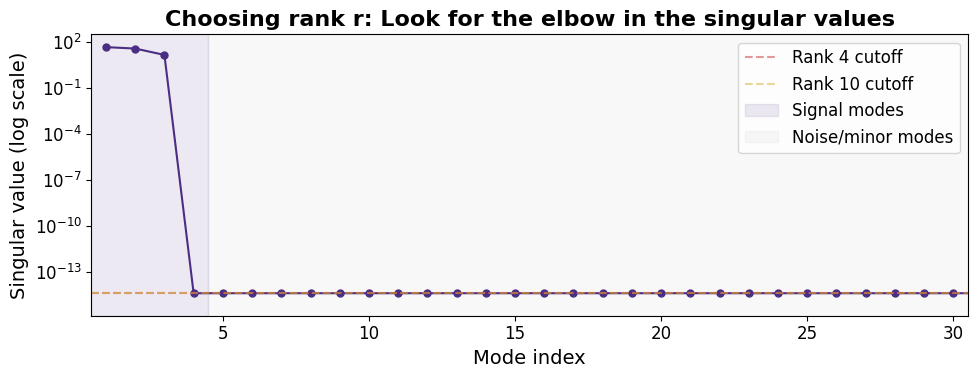

Practical guidance:
  • For our B-scan, the first ~4 singular values dominate.
  • Using r=4 captures the main wrinkle + base profile.
  • Using r=10 is safe (includes some minor modes, no harm).
  • Using r=2 would miss the wrinkle if it has both sin+cos components.

Rule of thumb: r ≥ 2 × (number of wrinkle frequencies you expect) + 1
  e.g., 1 wrinkle → r ≥ 3,  2 wrinkles → r ≥ 5


In [ ]:
# ── How to choose rank r: look at the singular values ──
_, S_rank, _ = np.linalg.svd(X_wrinkled[:, :-1], full_matrices=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(range(1, len(S_rank)+1), S_rank, 'o-', color=UW_PURPLE, markersize=5)
ax.axhline(S_rank[3], color='#CC3333', linestyle='--', alpha=0.5, label=f'Rank 4 cutoff')
ax.axhline(S_rank[9], color=ACCENT_GOLD, linestyle='--', alpha=0.5, label=f'Rank 10 cutoff')

# Shade the "signal" region
ax.axvspan(0.5, 4.5, alpha=0.1, color=UW_PURPLE, label='Signal modes')
ax.axvspan(4.5, 63.5, alpha=0.05, color='gray', label='Noise/minor modes')

ax.set_xlabel('Mode index')
ax.set_ylabel('Singular value (log scale)')
ax.set_title('Choosing rank r: Look for the elbow in the singular values', fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim(0.5, 30.5)
plt.tight_layout()
plt.show()

print('Practical guidance:')
print(f'  • For our B-scan, the first ~4 singular values dominate.')
print(f'  • Using r=4 captures the main wrinkle + base profile.')
print(f'  • Using r=10 is safe (includes some minor modes, no harm).')
print(f'  • Using r=2 would miss the wrinkle if it has both sin+cos components.')
print()
print('Rule of thumb: r ≥ 2 × (number of wrinkle frequencies you expect) + 1')
print('  e.g., 1 wrinkle → r ≥ 3,  2 wrinkles → r ≥ 5')

---
## Cell 7: Stress Test — Noise + Multiple Wrinkles

Real ultrasound data is noisy and may contain multiple defects. Let's test:

- **Wrinkle 1:** λ = 10mm (amplitude = 5)
- **Wrinkle 2:** λ = 20mm (amplitude = 3, weaker)
- **Noise:** σ = 0.15 (moderate)

Can DMD separate and identify both wavelengths?

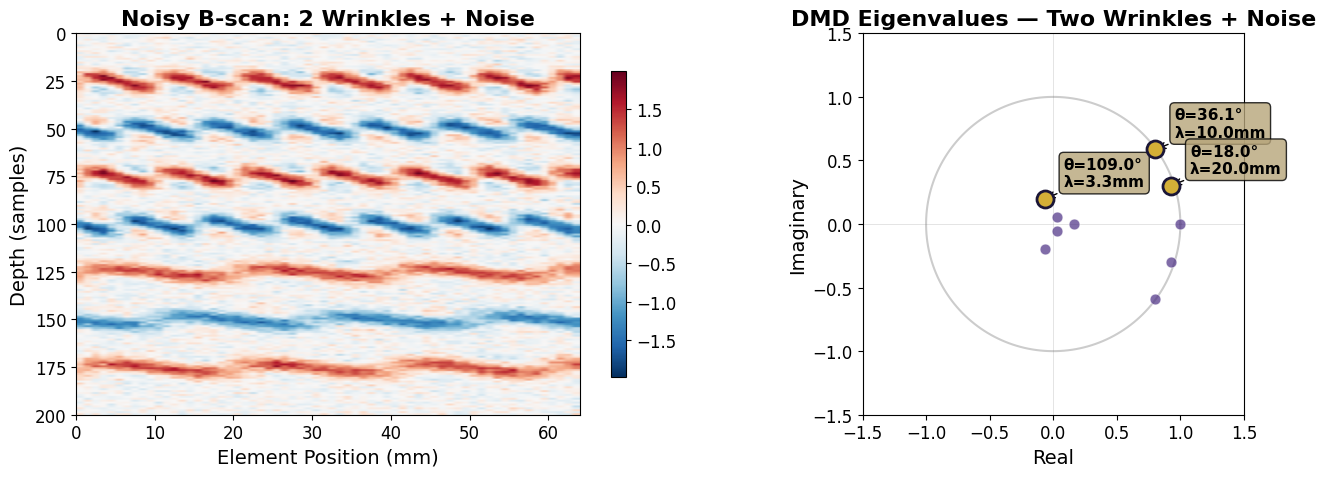

Expected wavelengths: 10mm (θ=36°) and 20mm (θ=18°)

Detected eigenvalues (positive angle, sorted by magnitude):
  θ = 36.1°  →  λ = 10.0mm  ← ~10mm wrinkle
  θ = 18.0°  →  λ = 20.0mm  ← ~20mm wrinkle
  θ = 109.0°  →  λ = 3.3mm  

DMD separates the two wrinkle frequencies even with noise!


In [ ]:
# ── Noisy B-scan with TWO wrinkles ──
X_hard = generate_bscan(
    wrinkle_wavelengths=[10, 20],
    wrinkle_amplitudes=[5.0, 3.0],
    noise_level=0.15,
    seed=42
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(X_hard, aspect='auto', cmap='RdBu_r', origin='upper',
                     extent=[0, 64, 200, 0])
axes[0].set_title('Noisy B-scan: 2 Wrinkles + Noise', fontweight='bold')
axes[0].set_xlabel('Element Position (mm)')
axes[0].set_ylabel('Depth (samples)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# DMD
evals_hard, modes_hard, _ = run_dmd(X_hard, r=10)

# Unit circle
theta_c = np.linspace(0, 2*np.pi, 200)
axes[1].plot(np.cos(theta_c), np.sin(theta_c), 'k-', alpha=0.2)
axes[1].axhline(0, color='gray', linewidth=0.5, alpha=0.3)
axes[1].axvline(0, color='gray', linewidth=0.5, alpha=0.3)
axes[1].scatter(evals_hard.real, evals_hard.imag, c=UW_PURPLE, s=60,
                edgecolors='white', linewidth=0.5, zorder=5, alpha=0.7)

# Annotate
angles_h = np.angle(evals_hard, deg=True)
mags_h = np.abs(evals_hard)
pos_mask = angles_h > 1
if np.any(pos_mask):
    pos_idx = np.where(pos_mask)[0]
    top_idx = pos_idx[np.argsort(-mags_h[pos_idx])][:3]
    for idx in top_idx:
        ev = evals_hard[idx]
        ang = angles_h[idx]
        wl = 360.0 / abs(ang)
        axes[1].scatter(ev.real, ev.imag, c=ACCENT_GOLD, s=150,
                        edgecolors=UW_DARK, linewidth=2, zorder=10)
        axes[1].annotate(f'θ={ang:.1f}°\nλ={wl:.1f}mm',
                         (ev.real, ev.imag),
                         xytext=(ev.real + 0.15, ev.imag + 0.1),
                         fontsize=11, fontweight='bold',
                         bbox=dict(boxstyle='round', facecolor=UW_GOLD, alpha=0.8),
                         arrowprops=dict(arrowstyle='->'))

axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_aspect('equal')
axes[1].set_title('DMD Eigenvalues — Two Wrinkles + Noise', fontweight='bold')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Imaginary')

plt.tight_layout()
plt.show()

# Print results
print('Expected wavelengths: 10mm (θ=36°) and 20mm (θ=18°)')
print()
print('Detected eigenvalues (positive angle, sorted by magnitude):')
if np.any(pos_mask):
    for idx in top_idx:
        ang = angles_h[idx]
        wl = 360.0 / abs(ang)
        expected = '← ~10mm wrinkle' if abs(wl - 10) < 3 else ('← ~20mm wrinkle' if abs(wl - 20) < 5 else '')
        print(f'  θ = {ang:.1f}°  →  λ = {wl:.1f}mm  {expected}')
print()
print('DMD separates the two wrinkle frequencies even with noise!')

---
## Cell 8: Playground — Build Your Intuition!

**Change the parameters below and re-run this cell.**

Things to try:
- `WRINKLE_WAVELENGTH = 5` → eigenvalue jumps to θ = 72° (faster oscillation)
- `WRINKLE_WAVELENGTH = 20` → eigenvalue drops to θ = 18° (slower oscillation)
- `NOISE_LEVEL = 0.5` → eigenvalues scatter but dominant one stays put
- `SECOND_WAVELENGTH = 20` → two pairs of eigenvalues appear!

**Watch:** As wavelength ↑, the eigenvalue angle ↓ (moves toward θ=0°)

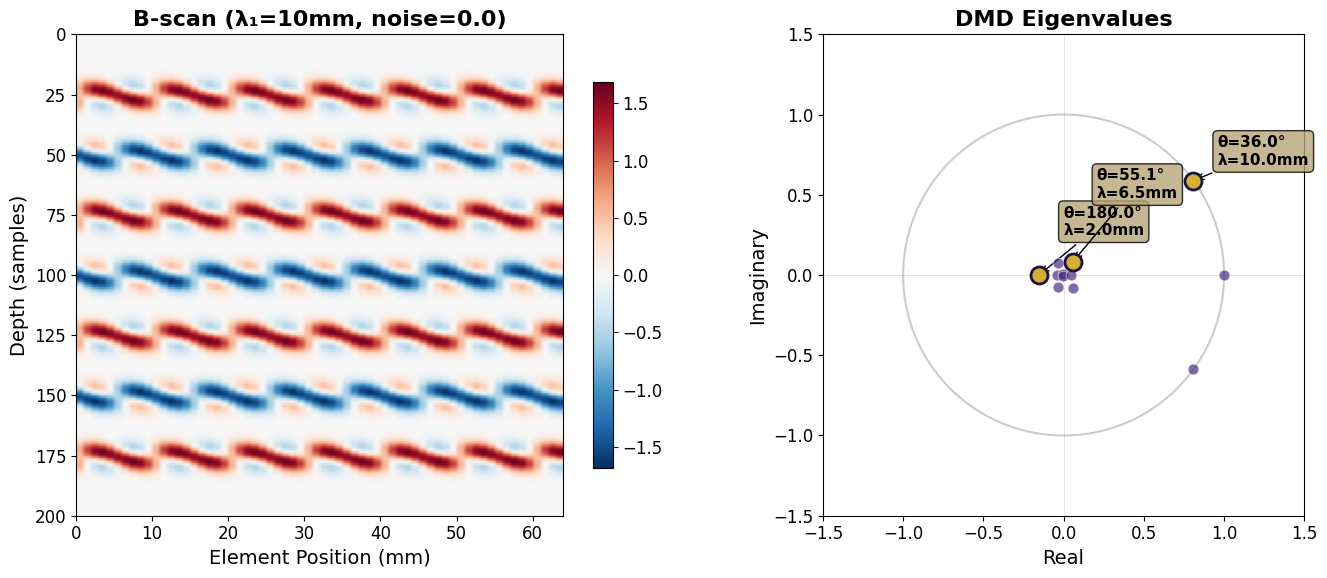

Expected: θ = 36.0° → λ = 10mm

Detected (top eigenvalues with positive angle):
  θ = 36.0° → λ = 10.0mm
  θ = 180.0° → λ = 2.0mm
  θ = 55.1° → λ = 6.5mm


In [ ]:
# ╔══════════════════════════════════════════╗
# ║  CHANGE THESE PARAMETERS AND RE-RUN!     ║
# ╚══════════════════════════════════════════╝

WRINKLE_WAVELENGTH = 10     # Try: 5, 8, 10, 15, 20, 32
NOISE_LEVEL = 0.0           # Try: 0.0, 0.3, 0.5, 1.0
SECOND_WAVELENGTH = None    # Try: None, 5, 15, 20, 32

# ── Build the data ──
wavelengths = [WRINKLE_WAVELENGTH]
amplitudes = [5.0]
if SECOND_WAVELENGTH is not None:
    wavelengths.append(SECOND_WAVELENGTH)
    amplitudes.append(3.0)

X_play = generate_bscan(
    wrinkle_wavelengths=wavelengths,
    wrinkle_amplitudes=amplitudes,
    noise_level=NOISE_LEVEL,
    seed=42
)

# ── Run DMD ──
evals_play, _, _ = run_dmd(X_play, r=12)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# B-scan
im = axes[0].imshow(X_play, aspect='auto', cmap='RdBu_r', origin='upper',
                     extent=[0, 64, 200, 0])
wl_str = f'λ₁={WRINKLE_WAVELENGTH}mm'
if SECOND_WAVELENGTH:
    wl_str += f', λ₂={SECOND_WAVELENGTH}mm'
axes[0].set_title(f'B-scan ({wl_str}, noise={NOISE_LEVEL})', fontweight='bold')
axes[0].set_xlabel('Element Position (mm)')
axes[0].set_ylabel('Depth (samples)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Unit circle
theta_c = np.linspace(0, 2*np.pi, 200)
axes[1].plot(np.cos(theta_c), np.sin(theta_c), 'k-', alpha=0.2)
axes[1].axhline(0, color='gray', linewidth=0.5, alpha=0.3)
axes[1].axvline(0, color='gray', linewidth=0.5, alpha=0.3)
axes[1].scatter(evals_play.real, evals_play.imag, c=UW_PURPLE, s=60,
                edgecolors='white', linewidth=0.5, zorder=5, alpha=0.7)

# Annotate dominant eigenvalues
angles_play = np.angle(evals_play, deg=True)
mags_play = np.abs(evals_play)
pos_mask = angles_play > 1
if np.any(pos_mask):
    pos_idx = np.where(pos_mask)[0]
    top_idx = pos_idx[np.argsort(-mags_play[pos_idx])][:3]
    for i, idx in enumerate(top_idx):
        ev = evals_play[idx]
        ang = angles_play[idx]
        wl = 360.0 / abs(ang)
        axes[1].scatter(ev.real, ev.imag, c=ACCENT_GOLD, s=150,
                        edgecolors=UW_DARK, linewidth=2, zorder=10)
        axes[1].annotate(f'θ={ang:.1f}°\nλ={wl:.1f}mm',
                         (ev.real, ev.imag),
                         xytext=(ev.real + 0.15, ev.imag + 0.1 + i*0.15),
                         fontsize=11, fontweight='bold',
                         bbox=dict(boxstyle='round', facecolor=UW_GOLD, alpha=0.8),
                         arrowprops=dict(arrowstyle='->'))

axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_aspect('equal')
axes[1].set_title('DMD Eigenvalues', fontweight='bold')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Imaginary')

plt.tight_layout()
plt.show()

# Expected vs detected
print(f'Expected: θ = {360/WRINKLE_WAVELENGTH:.1f}° → λ = {WRINKLE_WAVELENGTH}mm')
if SECOND_WAVELENGTH:
    print(f'Expected: θ = {360/SECOND_WAVELENGTH:.1f}° → λ = {SECOND_WAVELENGTH}mm')
print()
print('Detected (top eigenvalues with positive angle):')
if np.any(pos_mask):
    for idx in top_idx:
        ang = angles_play[idx]
        wl = 360.0 / abs(ang)
        print(f'  θ = {ang:.1f}° → λ = {wl:.1f}mm')

---
## Cell 9: Application: Classifying Wrinkle Severity with K-Means

In practice, we don't just detect ONE wrinkle. We scan many B-scans from different parts of the composite and want to classify them by severity.

**Idea:** Run DMD on each B-scan, extract the dominant eigenvalue angle, and cluster the angles using K-means:
- **Cluster 1 (small θ, large λ):** Gentle, wide wrinkles, less severe
- **Cluster 2 (large θ, small λ):** Tight, short wrinkles, more severe
- **Cluster 3 (θ ≈ 0):** No wrinkle, healthy

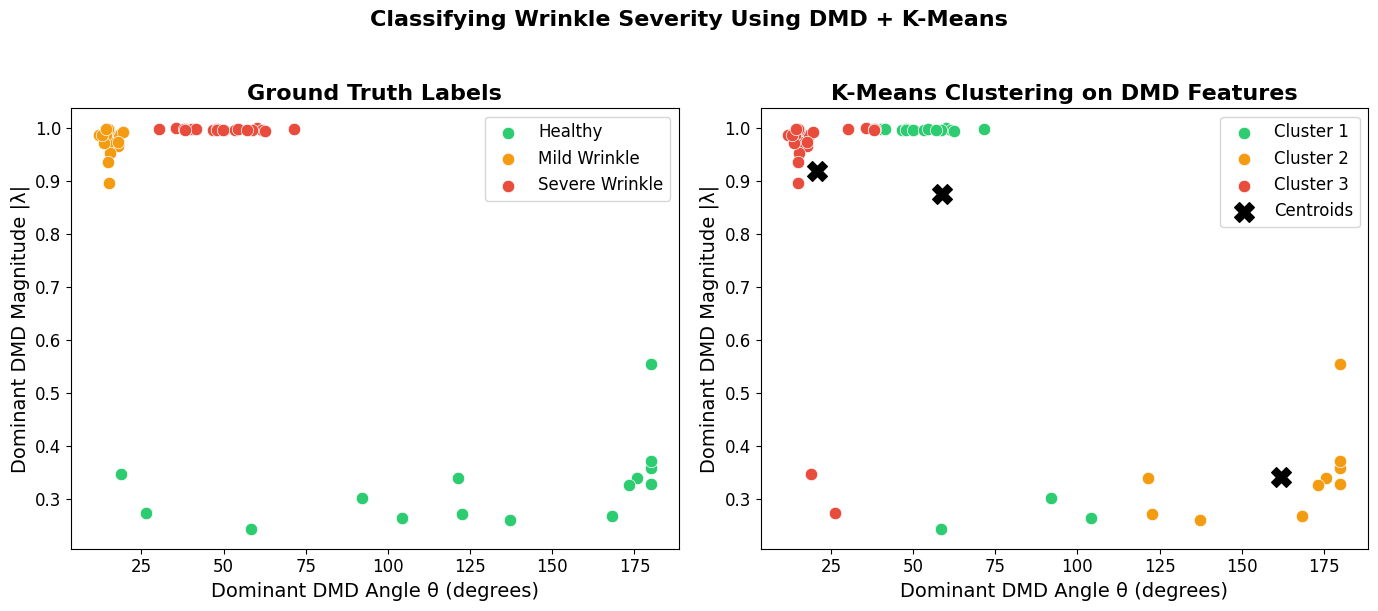

Cluster Centroids:
  Cluster 1: θ = 58.8°, |λ| = 0.876  →  wavelength ≈ 6mm
  Cluster 2: θ = 161.8°, |λ| = 0.341  →  wavelength ≈ 2mm
  Cluster 3: θ = 20.8°, |λ| = 0.919  →  wavelength ≈ 17mm

This is exactly how we classify wrinkle severity in practice:
  1. Run DMD on each B-scan segment
  2. Extract eigenvalue angles as features
  3. Cluster or classify based on angle + magnitude
  4. Map clusters to physical wrinkle categories


In [ ]:
from sklearn.cluster import KMeans

# ── Generate a batch of B-scans with varying wrinkle parameters ──
np.random.seed(42)
n_samples = 50

# Create samples with 3 categories:
# Category 1: Healthy (no wrinkle)
# Category 2: Mild wrinkle (λ = 20-30mm, low amplitude)
# Category 3: Severe wrinkle (λ = 5-12mm, high amplitude)
features = []  # will store (dominant_angle, dominant_magnitude) per sample
true_labels = []
sample_params = []

for i in range(n_samples):
    if i < 15:
        # Healthy
        wls, amps = [], []
        true_labels.append(0)
        label = 'Healthy'
    elif i < 30:
        # Mild wrinkle
        wl = np.random.uniform(18, 30)
        amp = np.random.uniform(1.0, 3.0)
        wls, amps = [wl], [amp]
        true_labels.append(1)
        label = 'Mild'
    else:
        # Severe wrinkle
        wl = np.random.uniform(5, 12)
        amp = np.random.uniform(4.0, 7.0)
        wls, amps = [wl], [amp]
        true_labels.append(2)
        label = 'Severe'

    noise = np.random.uniform(0.05, 0.2)
    X_sample = generate_bscan(wrinkle_wavelengths=wls, wrinkle_amplitudes=amps,
                               noise_level=noise, seed=i*7)

    # Run DMD and extract features
    evals_s, _, _ = run_dmd(X_sample, r=8)
    angles_s = np.angle(evals_s, deg=True)
    mags_s = np.abs(evals_s)

    # Feature: dominant eigenvalue angle (positive, non-DC)
    pos_mask = angles_s > 1
    if np.any(pos_mask):
        pos_idx = np.where(pos_mask)[0]
        best = pos_idx[np.argmax(mags_s[pos_idx])]
        dom_angle = angles_s[best]
        dom_mag = mags_s[best]
    else:
        dom_angle = 0.0
        dom_mag = 0.0

    features.append([dom_angle, dom_mag])
    sample_params.append((label, wls, amps))

features = np.array(features)
true_labels = np.array(true_labels)

# ── K-means clustering on DMD features ──
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pred_labels = kmeans.fit_predict(features)

# ── Visualize ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ground truth
colors_true = ['#2ecc71', '#f39c12', '#e74c3c']
labels_true = ['Healthy', 'Mild Wrinkle', 'Severe Wrinkle']
for k in range(3):
    mask = true_labels == k
    axes[0].scatter(features[mask, 0], features[mask, 1],
                    c=colors_true[k], s=80, label=labels_true[k],
                    edgecolors='white', linewidth=0.5)

axes[0].set_xlabel('Dominant DMD Angle θ (degrees)')
axes[0].set_ylabel('Dominant DMD Magnitude |λ|')
axes[0].set_title('Ground Truth Labels', fontweight='bold')
axes[0].legend()

# K-means clusters
colors_km = ['#2ecc71', '#f39c12', '#e74c3c']
for k in range(3):
    mask = pred_labels == k
    axes[1].scatter(features[mask, 0], features[mask, 1],
                    c=colors_km[k], s=80, edgecolors='white', linewidth=0.5,
                    label=f'Cluster {k+1}')

# Cluster centers
centers = kmeans.cluster_centers_
axes[1].scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='X',
                zorder=10, label='Centroids')

axes[1].set_xlabel('Dominant DMD Angle θ (degrees)')
axes[1].set_ylabel('Dominant DMD Magnitude |λ|')
axes[1].set_title('K-Means Clustering on DMD Features', fontweight='bold')
axes[1].legend()

plt.suptitle('Classifying Wrinkle Severity Using DMD + K-Means',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print cluster analysis
print('Cluster Centroids:')
for k in range(3):
    angle, mag = centers[k]
    if angle > 1:
        wl = 360.0 / angle
        print(f'  Cluster {k+1}: θ = {angle:.1f}°, |λ| = {mag:.3f}  →  wavelength ≈ {wl:.0f}mm')
    else:
        print(f'  Cluster {k+1}: θ ≈ 0°, |λ| = {mag:.3f}  →  no oscillation (healthy)')
print()
print('This is exactly how we classify wrinkle severity in practice:')
print('  1. Run DMD on each B-scan segment')
print('  2. Extract eigenvalue angles as features')
print('  3. Cluster or classify based on angle + magnitude')
print('  4. Map clusters to physical wrinkle categories')

---
## Cell 10: When Does DMD Struggle?

DMD assumes **linear dynamics**: each column is approximately a linear function of the previous one. This works perfectly for sinusoidal wrinkles.

But what about **nonlinear** defects? A square-wave wrinkle (abrupt jumps instead of smooth oscillation) can't be captured by a single DMD mode. Just like Fourier series, DMD needs multiple harmonics.

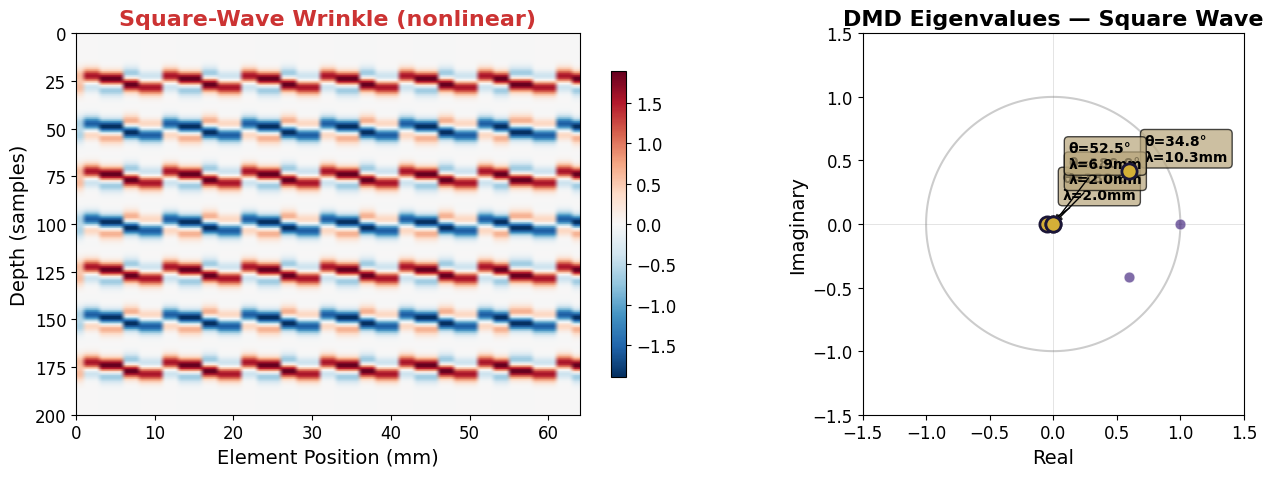

What happened?
  A square wave = fundamental + odd harmonics (3rd, 5th, 7th...)
  Fundamental: λ=10mm → θ=36°
  3rd harmonic: λ=3.3mm → θ=108°
  5th harmonic: λ=2.0mm → θ=180°

DMD detects the fundamental + harmonics — multiple modes needed.
For strongly nonlinear dynamics: consider extended DMD or kernel DMD.

Good news: real composite wrinkles have a lot more noise, but are smooth,
so we use some variations of DMD like MrDMD with optimization techniques


In [ ]:
# ── Square-wave wrinkle: a nonlinear challenge ──
n_elements = 64
n_depth = 200
sq_wavelength = 10

depth = np.arange(n_depth)
ply_positions = np.linspace(25, 175, 7)

# Build base profile
base = np.zeros(n_depth)
for pi, pp in enumerate(ply_positions):
    pol = 1 if pi % 2 == 0 else -1
    base += pol * np.exp(-0.5 * ((depth - pp) / 3.0) ** 2)

mode_disp = np.gradient(base)
mode_curv = np.gradient(mode_disp)

# Square wave version: sign(sin) instead of sin
X_square = np.zeros((n_depth, n_elements))
for j in range(n_elements):
    sq_sin = np.sign(np.sin(2 * np.pi * j / sq_wavelength))
    sq_cos = np.sign(np.cos(2 * np.pi * j / sq_wavelength))
    X_square[:, j] = base + 5.0 * (sq_sin * mode_disp + sq_cos * mode_curv)

# DMD
evals_sq, _, _ = run_dmd(X_square, r=15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(X_square, aspect='auto', cmap='RdBu_r', origin='upper',
                     extent=[0, 64, 200, 0])
axes[0].set_title('Square-Wave Wrinkle (nonlinear)', fontweight='bold', color='#CC3333')
axes[0].set_xlabel('Element Position (mm)')
axes[0].set_ylabel('Depth (samples)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Unit circle
theta_c = np.linspace(0, 2*np.pi, 200)
axes[1].plot(np.cos(theta_c), np.sin(theta_c), 'k-', alpha=0.2)
axes[1].axhline(0, color='gray', linewidth=0.5, alpha=0.3)
axes[1].axvline(0, color='gray', linewidth=0.5, alpha=0.3)
axes[1].scatter(evals_sq.real, evals_sq.imag, c=UW_PURPLE, s=60,
                edgecolors='white', linewidth=0.5, zorder=5, alpha=0.7)

# Annotate
angles_sq = np.angle(evals_sq, deg=True)
mags_sq = np.abs(evals_sq)
pos_mask = angles_sq > 1
if np.any(pos_mask):
    pos_idx = np.where(pos_mask)[0]
    top_idx = pos_idx[np.argsort(-mags_sq[pos_idx])][:4]
    for i, idx in enumerate(top_idx):
        ev = evals_sq[idx]
        ang = angles_sq[idx]
        wl = 360.0 / abs(ang)
        axes[1].scatter(ev.real, ev.imag, c=ACCENT_GOLD, s=120,
                        edgecolors=UW_DARK, linewidth=2, zorder=10)
        axes[1].annotate(f'θ={ang:.1f}°\nλ={wl:.1f}mm',
                         (ev.real, ev.imag),
                         xytext=(ev.real + 0.12, ev.imag + 0.08 + i*0.12),
                         fontsize=10, fontweight='bold',
                         bbox=dict(boxstyle='round', facecolor=UW_GOLD, alpha=0.7),
                         arrowprops=dict(arrowstyle='->'))

axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_aspect('equal')
axes[1].set_title('DMD Eigenvalues — Square Wave', fontweight='bold')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Imaginary')

plt.tight_layout()
plt.show()

print('What happened?')
print(f'  A square wave = fundamental + odd harmonics (3rd, 5th, 7th...)')
print(f'  Fundamental: λ={sq_wavelength}mm → θ={360/sq_wavelength:.0f}°')
print(f'  3rd harmonic: λ={sq_wavelength/3:.1f}mm → θ={360*3/sq_wavelength:.0f}°')
print(f'  5th harmonic: λ={sq_wavelength/5:.1f}mm → θ={360*5/sq_wavelength:.0f}°')
print()
print('DMD detects the fundamental + harmonics — multiple modes needed.')
print('For strongly nonlinear dynamics: consider extended DMD or kernel DMD.')
print()
print('Good news: real composite wrinkles have a lot more noise, but are smooth,')
print('so we use some variations of DMD like MrDMD with optimization techniques')

---
## Summary

| | PCA | DMD |
|---|---|---|
| **Input** | Data matrix X (unordered columns) | Sequential data X₁, X₂ (ordered columns) |
| **Core operation** | SVD of X | SVD of X₁ + eigendecompose dynamics operator |
| **Eigenvalues** | Real → variance explained | Complex → oscillation frequency |
| **Column ordering** | Doesn't matter (shuffle = same result) | Essential (captures sequential dynamics) |
| **Wrinkle detection** | Finds high-variance regions | Finds wrinkle wavelength directly |

### The key formula

**DMD eigenvalue angle θ → spatial frequency → wrinkle wavelength λ = 360°/θ × pitch**

The eigenvalue on the unit circle *is* the wrinkle's spatial frequency. That's something PCA cannot give you.

### The pipeline for wrinkle classification

1. **Acquire** B-scan data from phased array ultrasound
2. **Run DMD** → extract eigenvalue angles (wrinkle frequencies)
3. **Cluster** eigenvalues with K-means → classify severity
4. **Map** clusters to engineering categories (healthy, mild, severe)



### Assumptions & Limitations (for real-world use)

- **Sampling:** The probe must have ≥ 2 elements per wrinkle wavelength (Nyquist). With 1mm pitch, the shortest detectable wrinkle is λ = 2mm (θ = 180°).
- **Linearity:** DMD assumes each column is approximately a linear function of its neighbor. Strongly nonlinear defects (sharp edges, delaminations) need extended DMD or kernel DMD.
- **Rank selection:** Choose r based on the singular value drop-off (elbow method). Too small → miss wrinkles. Too large → include noise modes.
- **Overlapping frequencies:** If two wrinkles have very similar wavelengths (e.g., λ₁=10mm, λ₂=11mm), DMD may struggle to separate them — more elements help.


---
## Want to Learn More?

### Books & Papers

- **Kutz, Brunton, Brunton, & Proctor — *Data-Driven Science and Engineering*** (Cambridge, 2019)  
  Chapters 7–8 cover DMD with excellent Python examples. Free online at [databookuw.com](http://databookuw.com).

- **Brunton & Kutz — *Data-Driven Discovery of Dynamical Systems*** (tutorial paper)  
  Great for understanding when DMD works and when it breaks down.

- **Schmid (2010) — "Dynamic mode decomposition of numerical and experimental data"**  
  The original DMD paper. Worth reading the introduction for the core insight.

### Python Libraries

- **[PyDMD](https://github.com/mathLab/PyDMD)** — Production-ready DMD library with many variants (exact DMD, optimized DMD, multi-resolution DMD). Install with `pip install pydmd`.

- **[PySINDy](https://github.com/dynamicslab/pysindy)** — For going beyond DMD to discover nonlinear governing equations from data.

### Datasets to Practice On

- **Flow past a cylinder** — Classic DMD benchmark. Download from [dmdbook.com/DATA.zip](http://dmdbook.com/DATA.zip). Try extracting the vortex shedding frequency!

- **Sea surface temperature** — Monthly SST anomalies from NOAA. DMD can find El Niño/La Niña oscillation frequencies. Available via `xarray.tutorial.load_dataset('air_temperature')`.

- **Video data** — Any video is a matrix (pixels × frames). Try DMD on a video of a vibrating beam or swaying grass to extract vibration modes.